# 0. Import all required libraries

In [35]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch
from datasets import Dataset
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import DataCollatorWithPadding


from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
df = pd.read_csv(r'/content/classified_tweets_2.csv', on_bad_lines='skip', usecols = ['text', 'emotion'] , engine='python')

In [9]:
df

,text,emotion,clean_text
0,10 Years Ago Welling United 0-1 Aldershot Town...,happiness,years ago welling united aldershot town vnl ro...
1,Thank you Coach Horton for a wonderful visit t...,happiness,thank you coach horton for a wonderful visit t...
2,"Remember years ago, softball used to be that w...",happiness,remember years ago softball used to be that wa...
3,KAMIL SEMENIUK The Italian league champion wil...,neutral,kamil semeniuk the italian league champion wil...
4,Nebraska beach volleyball earned a dominant 5-...,happiness,nebraska beach volleyball earned a dominant sw...
...,...,...,...
13049,That's a cool dino,happiness,thats a cool dino
13050,Shhh don't give them the idea!,anger,shhh dont give them the idea
13051,"Downtown is inconvenient, look like you've gon...",happiness,downtown is inconvenient look like youve gone ...
13052,My inevitable famine is when I run out of pop ...,sadness,my inevitable famine is when i run out of pop ...


In [5]:
#  Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()
print("\nData types:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nClass distribution (emotion):")
print(df['emotion'].value_counts())
print("\nBasic statistics for text length:")
df['text_length'] = df['text'].astype(str).str.len()
print(df['text_length'].describe())

Dataset shape: (13054, 2)

First 5 rows:

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13054 entries, 0 to 13053
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     13054 non-null  object
 1   emotion  13054 non-null  object
dtypes: object(2)
memory usage: 204.1+ KB

Missing values per column:
text       0
emotion    0
dtype: int64

Class distribution (emotion):
emotion
neutral      5083
happiness    3863
anger        1261
sadness      1122
surprise      741
disgust       507
fear          477
Name: count, dtype: int64

Basic statistics for text length:
count    13054.000000
mean       145.082810
std         83.619366
min          4.000000
25%         72.000000
50%        132.000000
75%        227.000000
max        280.000000
Name: text_length, dtype: float64


# 2. Data cleaning

In [6]:
# Remove rows with missing text or emotion
df = df.dropna(subset=['text', 'emotion'])

# Remove exact duplicate tweets (keeping first occurrence)
df = df.drop_duplicates(subset=['text'])

# Clean text: lowercase, remove URLs, mentions, hashtags, punctuation, digits
import re
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)                     # remove @mentions
    text = re.sub(r'#\w+', '', text)                     # remove hashtags (or keep words? remove for simplicity)
    text = re.sub(r'[^\w\s]', '', text)                  # remove punctuation
    text = re.sub(r'\d+', '', text)                      # remove digits
    text = re.sub(r'\s+', ' ', text).strip()             # extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_tweet)

# Remove rows where cleaned text is empty (very short after cleaning)
df = df[df['clean_text'].str.len() > 2]

# (Optional) Map emotion labels to consistent format (e.g., lowercase)
df['emotion'] = df['emotion'].str.lower().str.strip()

# Drop the temporary length column if you wish (or keep for EDA)
df.drop(columns=['text_length'], inplace=True)

print("After cleaning, dataset shape:", df.shape)

After cleaning, dataset shape: (13044, 3)


In [7]:
df

,text,emotion,clean_text
0,10 Years Ago Welling United 0-1 Aldershot Town...,happiness,years ago welling united aldershot town vnl ro...
1,Thank you Coach Horton for a wonderful visit t...,happiness,thank you coach horton for a wonderful visit t...
2,"Remember years ago, softball used to be that w...",happiness,remember years ago softball used to be that wa...
3,KAMIL SEMENIUK The Italian league champion wil...,neutral,kamil semeniuk the italian league champion wil...
4,Nebraska beach volleyball earned a dominant 5-...,happiness,nebraska beach volleyball earned a dominant sw...
...,...,...,...
13049,That's a cool dino,happiness,thats a cool dino
13050,Shhh don't give them the idea!,anger,shhh dont give them the idea
13051,"Downtown is inconvenient, look like you've gon...",happiness,downtown is inconvenient look like youve gone ...
13052,My inevitable famine is when I run out of pop ...,sadness,my inevitable famine is when i run out of pop ...


# 3. Claude Data preprocessing and EDA

In [11]:

#  DATA CLEANING, EDA & PREPARATION  —  Volleyball Tweet Emotions
#  Diploma Work  |  Multi-class Text Classification
# ============================================================

# ── 0. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re
import string
import warnings

from sklearn.preprocessing import LabelEncoder

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────
PALETTE  = "viridis"
BG_COLOR = "#f9f9f9"
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   BG_COLOR,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})
STOP_EN = set(stopwords.words('english'))



In [12]:

# ================================================================
# 1. LOAD DATA
# ================================================================

df_raw = pd.read_csv(
    r'/content/classified_tweets_2.csv',
    on_bad_lines='skip',
    usecols=['text', 'emotion'],
    engine='python',
)

print("=" * 55)
print("  RAW DATASET — INITIAL SNAPSHOT")
print("=" * 55)
print(f"Shape          : {df_raw.shape}")
print(f"Columns        : {df_raw.columns.tolist()}")
print(f"\nData types:\n{df_raw.dtypes}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nDuplicate rows : {df_raw.duplicated().sum()}")
print(f"\nEmotion classes:\n{df_raw['emotion'].value_counts()}")
print(f"\nSample tweets:")
display(df_raw.sample(5, random_state=42))



  RAW DATASET — INITIAL SNAPSHOT
Shape          : (13054, 2)
Columns        : ['text', 'emotion']

Data types:
text       object
emotion    object
dtype: object

Missing values:
text       0
emotion    0
dtype: int64

Duplicate rows : 9

Emotion classes:
emotion
neutral      5083
happiness    3863
anger        1261
sadness      1122
surprise      741
disgust       507
fear          477
Name: count, dtype: int64

Sample tweets:


,text,emotion
2614,when coach kasper keeps taking the risk of sta...,neutral
10003,Worst deal on the leafs right now easily,disgust
11478,Wow! There's no reason for this comment!,surprise
2924,I used to work 3rd shift and went after work. ...,neutral
2495,SILVER FOR #CRPF! Heartiest congratulations to...,happiness


In [13]:

# ================================================================
# 2. DATA QUALITY REPORT  (before cleaning)
# ================================================================

df = df_raw.copy()
df['text'] = df['text'].astype(str)

df['raw_len']        = df['text'].str.len()
df['raw_word_count'] = df['text'].str.split().str.len()
df['has_url']        = df['text'].str.contains(r'http\S+|www\S+', regex=True)
df['has_mention']    = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag']    = df['text'].str.contains(r'#\w+', regex=True)
df['has_emoji']      = df['text'].str.contains(
    u'[\U00010000-\U0010ffff]', flags=re.UNICODE, regex=True
)
df['is_retweet']     = df['text'].str.startswith('RT ')
df['all_caps_ratio'] = df['text'].apply(
    lambda t: sum(1 for c in t if c.isupper()) / max(len(t), 1)
)

print("\n" + "=" * 55)
print("  DATA QUALITY REPORT (before cleaning)")
print("=" * 55)
quality = {
    "Total rows":          len(df),
    "Missing text":        df['text'].isna().sum(),
    "Missing emotion":     df['emotion'].isna().sum(),
    "Exact duplicates":    df.duplicated(subset=['text']).sum(),
    "Rows with URL":       df['has_url'].sum(),
    "Rows with @mention":  df['has_mention'].sum(),
    "Rows with #hashtag":  df['has_hashtag'].sum(),
    "Retweets (RT)":       df['is_retweet'].sum(),
    "Rows with emoji":     df['has_emoji'].sum(),
    "Empty after strip":   (df['text'].str.strip() == '').sum(),
}
for k, v in quality.items():
    pct = f"({v/len(df)*100:.1f}%)" if "Total" not in k else ""
    print(f"  {k:<25} {v:>6}  {pct}")




  DATA QUALITY REPORT (before cleaning)
  Total rows                 13054  
  Missing text                   0  (0.0%)
  Missing emotion                0  (0.0%)
  Exact duplicates              10  (0.1%)
  Rows with URL                  0  (0.0%)
  Rows with @mention             0  (0.0%)
  Rows with #hashtag          2510  (19.2%)
  Retweets (RT)                  0  (0.0%)
  Rows with emoji               75  (0.6%)
  Empty after strip              0  (0.0%)


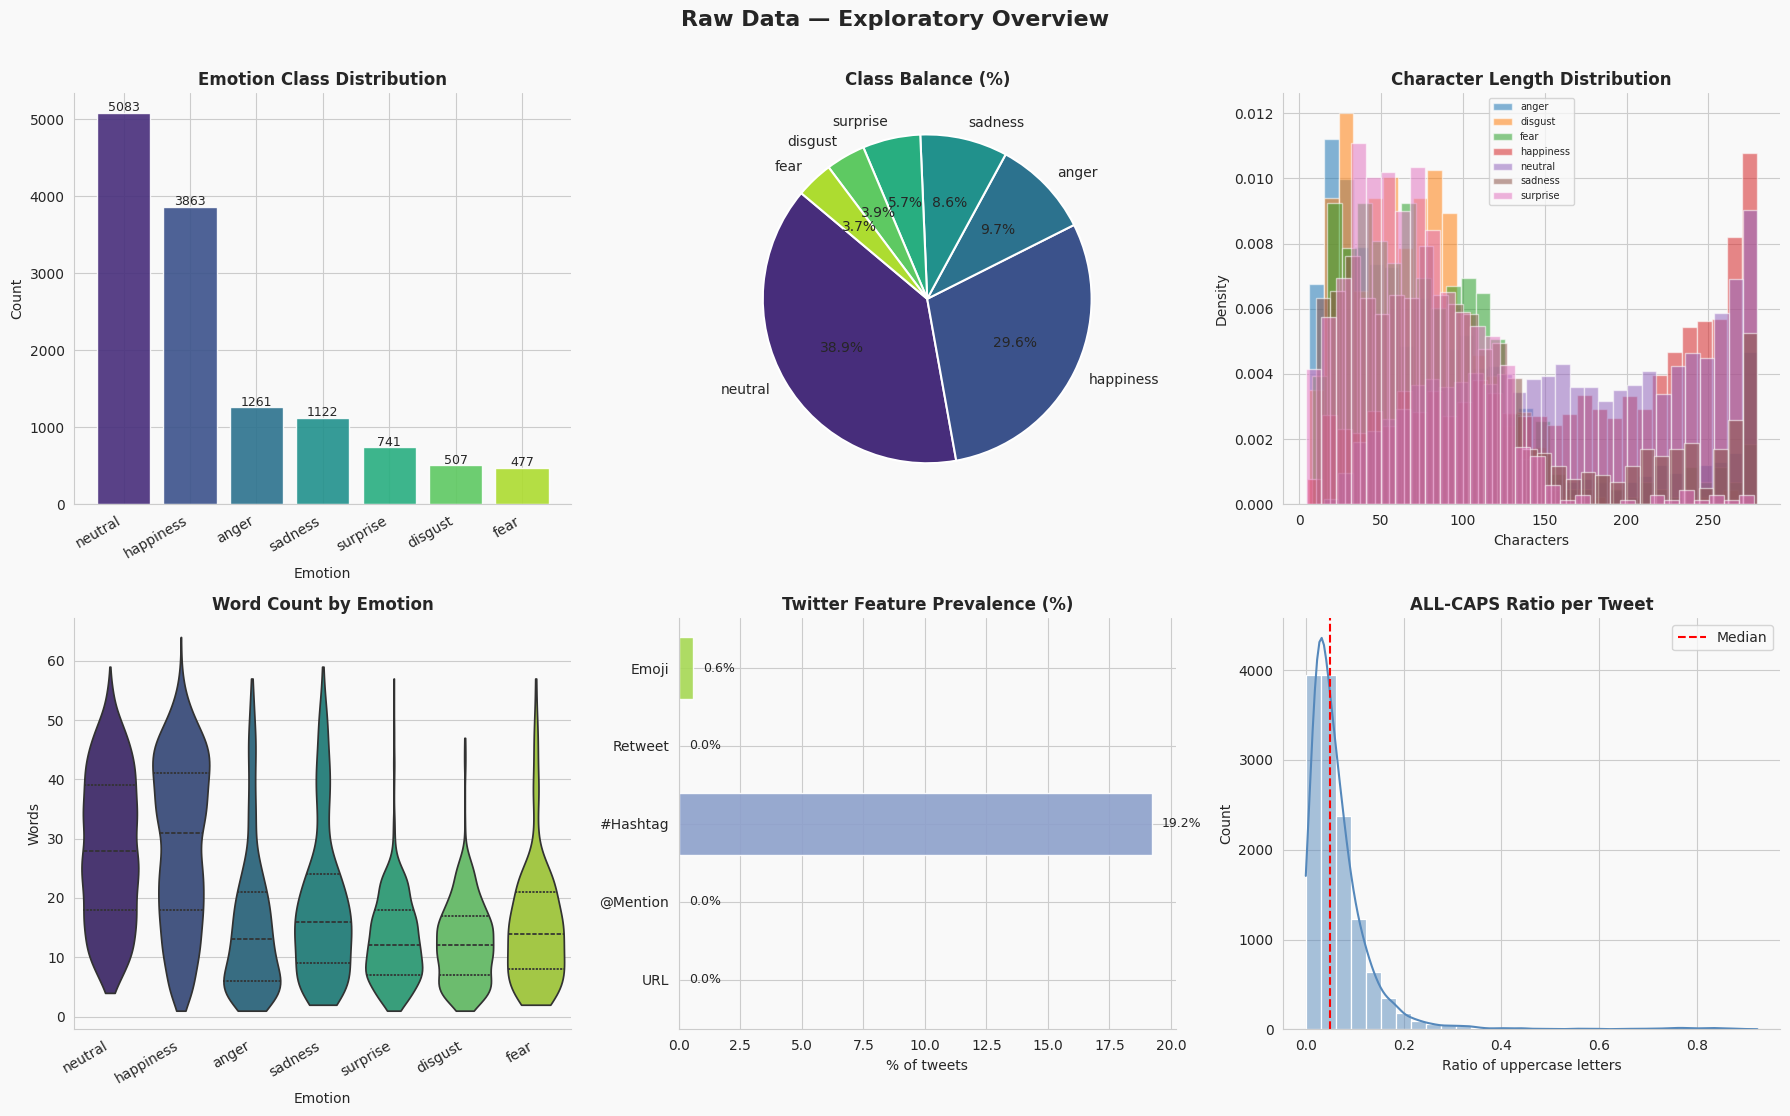

In [14]:

# ================================================================
# 3. VISUALISE RAW DATA PROPERTIES
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Raw Data — Exploratory Overview", fontsize=16, fontweight="bold", y=1.01)

# 3-1  Emotion distribution (bar)
ax = axes[0, 0]
vc = df['emotion'].value_counts()
bars = ax.bar(vc.index, vc.values,
              color=sns.color_palette(PALETTE, len(vc)), alpha=0.9, edgecolor='white')
ax.set_title("Emotion Class Distribution", fontweight="bold")
ax.set_ylabel("Count"); ax.set_xlabel("Emotion")
ax.set_xticklabels(vc.index, rotation=30, ha='right')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 20,
            str(int(b.get_height())), ha='center', fontsize=9)

# 3-2  Class balance pie
ax = axes[0, 1]
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       colors=sns.color_palette(PALETTE, len(vc)),
       startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title("Class Balance (%)", fontweight="bold")

# 3-3  Tweet character length histogram
ax = axes[0, 2]
for emo, grp in df.groupby('emotion'):
    ax.hist(grp['raw_len'], bins=30, alpha=0.55, label=emo, density=True)
ax.set_title("Character Length Distribution", fontweight="bold")
ax.set_xlabel("Characters"); ax.set_ylabel("Density")
ax.legend(fontsize=7)

# 3-4  Word count by emotion (violin)
ax = axes[1, 0]
order = df['emotion'].value_counts().index
sns.violinplot(data=df, x='emotion', y='raw_word_count', order=order,
               palette=PALETTE, inner='quartile', ax=ax, cut=0)
ax.set_title("Word Count by Emotion", fontweight="bold")
ax.set_xlabel("Emotion"); ax.set_ylabel("Words")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# 3-5  Twitter feature prevalence
ax = axes[1, 1]
features = ['has_url', 'has_mention', 'has_hashtag', 'is_retweet', 'has_emoji']
feat_labels = ['URL', '@Mention', '#Hashtag', 'Retweet', 'Emoji']
feat_pcts = [df[f].mean() * 100 for f in features]
bars2 = ax.barh(feat_labels, feat_pcts,
                color=sns.color_palette("Set2", len(features)), alpha=0.9)
ax.set_title("Twitter Feature Prevalence (%)", fontweight="bold")
ax.set_xlabel("% of tweets")
for b, v in zip(bars2, feat_pcts):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, f"{v:.1f}%", va='center', fontsize=9)

# 3-6  All-caps ratio distribution
ax = axes[1, 2]
sns.histplot(df['all_caps_ratio'], bins=30, kde=True, color="#5588bb", ax=ax)
ax.axvline(df['all_caps_ratio'].median(), color='red', linestyle='--', label='Median')
ax.set_title("ALL-CAPS Ratio per Tweet", fontweight="bold")
ax.set_xlabel("Ratio of uppercase letters"); ax.legend()

plt.tight_layout()
plt.savefig("eda_raw_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:

# ================================================================
# 4. TEXT LENGTH STATISTICS  TABLE
# ================================================================

print("\n" + "=" * 55)
print("  TEXT LENGTH STATS BY EMOTION (raw)")
print("=" * 55)
len_stats = df.groupby('emotion')['raw_len'].describe().round(1)
len_stats.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max']
display(len_stats)



  TEXT LENGTH STATS BY EMOTION (raw)


,Count,Mean,Std,Min,25%,Median,75%,Max
emotion,,,,,,,,
anger,1261.0,88.5,72.5,6.0,33.0,68.0,116.0,280.0
disgust,507.0,69.1,39.4,6.0,38.0,66.0,92.0,277.0
fear,477.0,84.5,58.4,8.0,41.0,72.0,108.0,280.0
happiness,3863.0,171.7,82.0,5.0,101.0,185.0,249.0,280.0
neutral,5083.0,172.0,73.7,15.0,109.0,174.0,240.0,280.0
sadness,1122.0,104.1,75.0,10.0,46.2,85.0,131.0,280.0
surprise,741.0,70.9,41.8,4.0,40.0,65.0,95.0,278.0


In [16]:

# ================================================================
# 5.  DEEP CLEANING PIPELINE
# ================================================================

print("\n" + "=" * 55)
print("  CLEANING PIPELINE")
print("=" * 55)

# ── Step 1: Drop nulls ───────────────────────────────────────
before = len(df)
df = df.dropna(subset=['text', 'emotion'])
print(f"[1] Drop nulls          : removed {before - len(df)} rows → {len(df)} remain")

# ── Step 2: Normalise emotion labels ────────────────────────
df['emotion'] = df['emotion'].str.lower().str.strip()
print(f"[2] Normalise emotion   : done. Classes → {sorted(df['emotion'].unique())}")

# ── Step 3: Remove exact duplicates ─────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['text'])
print(f"[3] Remove duplicates   : removed {before - len(df)} rows → {len(df)} remain")

# ── Step 4: Remove retweets ──────────────────────────────────
before = len(df)
df = df[~df['text'].str.startswith('RT ')]
print(f"[4] Remove retweets     : removed {before - len(df)} rows → {len(df)} remain")

# ── Step 5: Remove non-English heuristic (>40% non-ASCII) ───
def is_mostly_ascii(text, threshold=0.6):
    ascii_ratio = sum(c.isascii() for c in text) / max(len(text), 1)
    return ascii_ratio >= threshold

before = len(df)
df = df[df['text'].apply(is_mostly_ascii)]
print(f"[5] Non-English filter  : removed {before - len(df)} rows → {len(df)} remain")


  CLEANING PIPELINE
[1] Drop nulls          : removed 0 rows → 13054 remain
[2] Normalise emotion   : done. Classes → ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
[3] Remove duplicates   : removed 10 rows → 13044 remain
[4] Remove retweets     : removed 0 rows → 13044 remain
[5] Non-English filter  : removed 1 rows → 13043 remain


In [17]:


# ── Step 6: Text cleaning function ───────────────────────────
def clean_tweet(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                              # mentions
    text = re.sub(r'#(\w+)', r'\1', text)                         # keep hashtag word, remove #
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;|&#39;', ' ', text)    # HTML entities
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE)       # leftover RT
    text = text.encode('ascii', 'ignore').decode('ascii')         # strip non-ASCII/emoji
    text = re.sub(r'[^\w\s]', ' ', text)                          # punctuation → space
    text = re.sub(r'\d+', '', text)                               # digits
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_tweet)


In [19]:
# ── Step 7: Remove very short cleaned texts ──────────────────
before = len(df)
MIN_WORDS = 3
df = df[df['clean_text'].apply(lambda t: len(t.split()) >= MIN_WORDS)]
print(f"[6] Min {MIN_WORDS} words filter   : removed {before - len(df)} rows → {len(df)} remain")


[6] Min 3 words filter   : removed 91 rows → 12952 remain


In [20]:

# ── Step 8: Remove stopwords for analysis copy ───────────────
def remove_stopwords(text):
    return ' '.join(w for w in text.split() if w not in STOP_EN)

df['text_no_stop'] = df['clean_text'].apply(remove_stopwords)

In [21]:

# ── Step 9: Token count features ─────────────────────────────
df['clean_len']        = df['clean_text'].str.len()
df['word_count']       = df['clean_text'].str.split().str.len()
df['unique_words']     = df['clean_text'].apply(lambda t: len(set(t.split())))
df['lexical_diversity'] = df['unique_words'] / df['word_count'].clip(lower=1)
df['avg_word_len']     = df['clean_text'].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)

print("\n" + "=" * 55)
print(f"  DATASET AFTER CLEANING  →  {df.shape[0]} rows")
print("=" * 55)
print(f"Emotion distribution:\n{df['emotion'].value_counts()}")



  DATASET AFTER CLEANING  →  12952 rows
Emotion distribution:
emotion
neutral      5083
happiness    3847
anger        1225
sadness      1110
surprise      724
disgust       495
fear          468
Name: count, dtype: int64


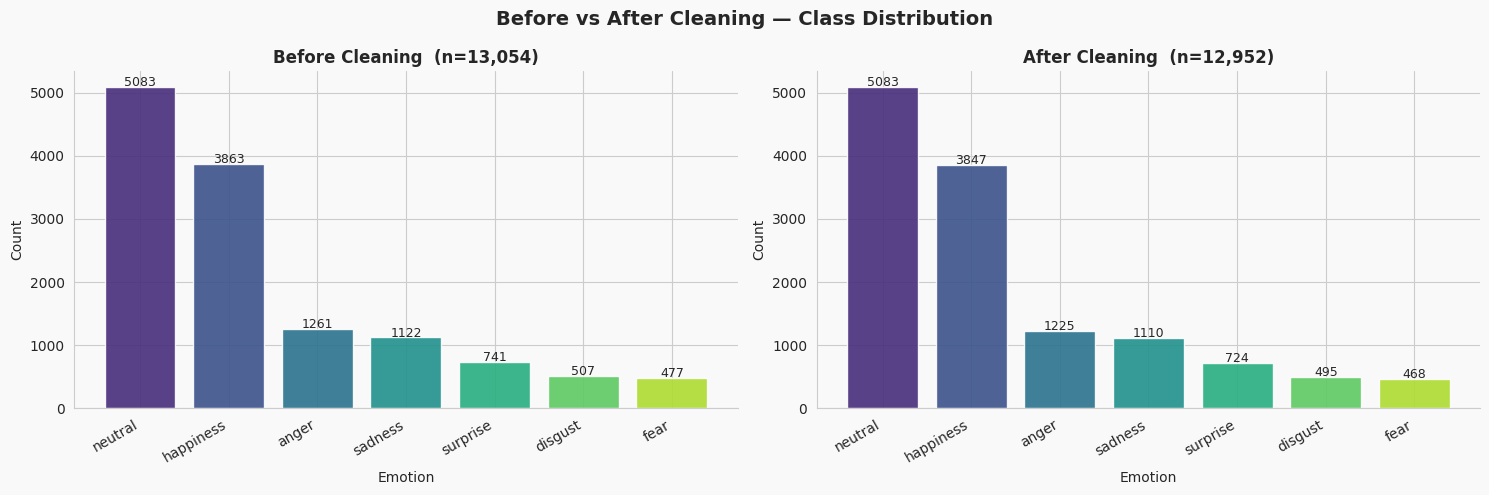

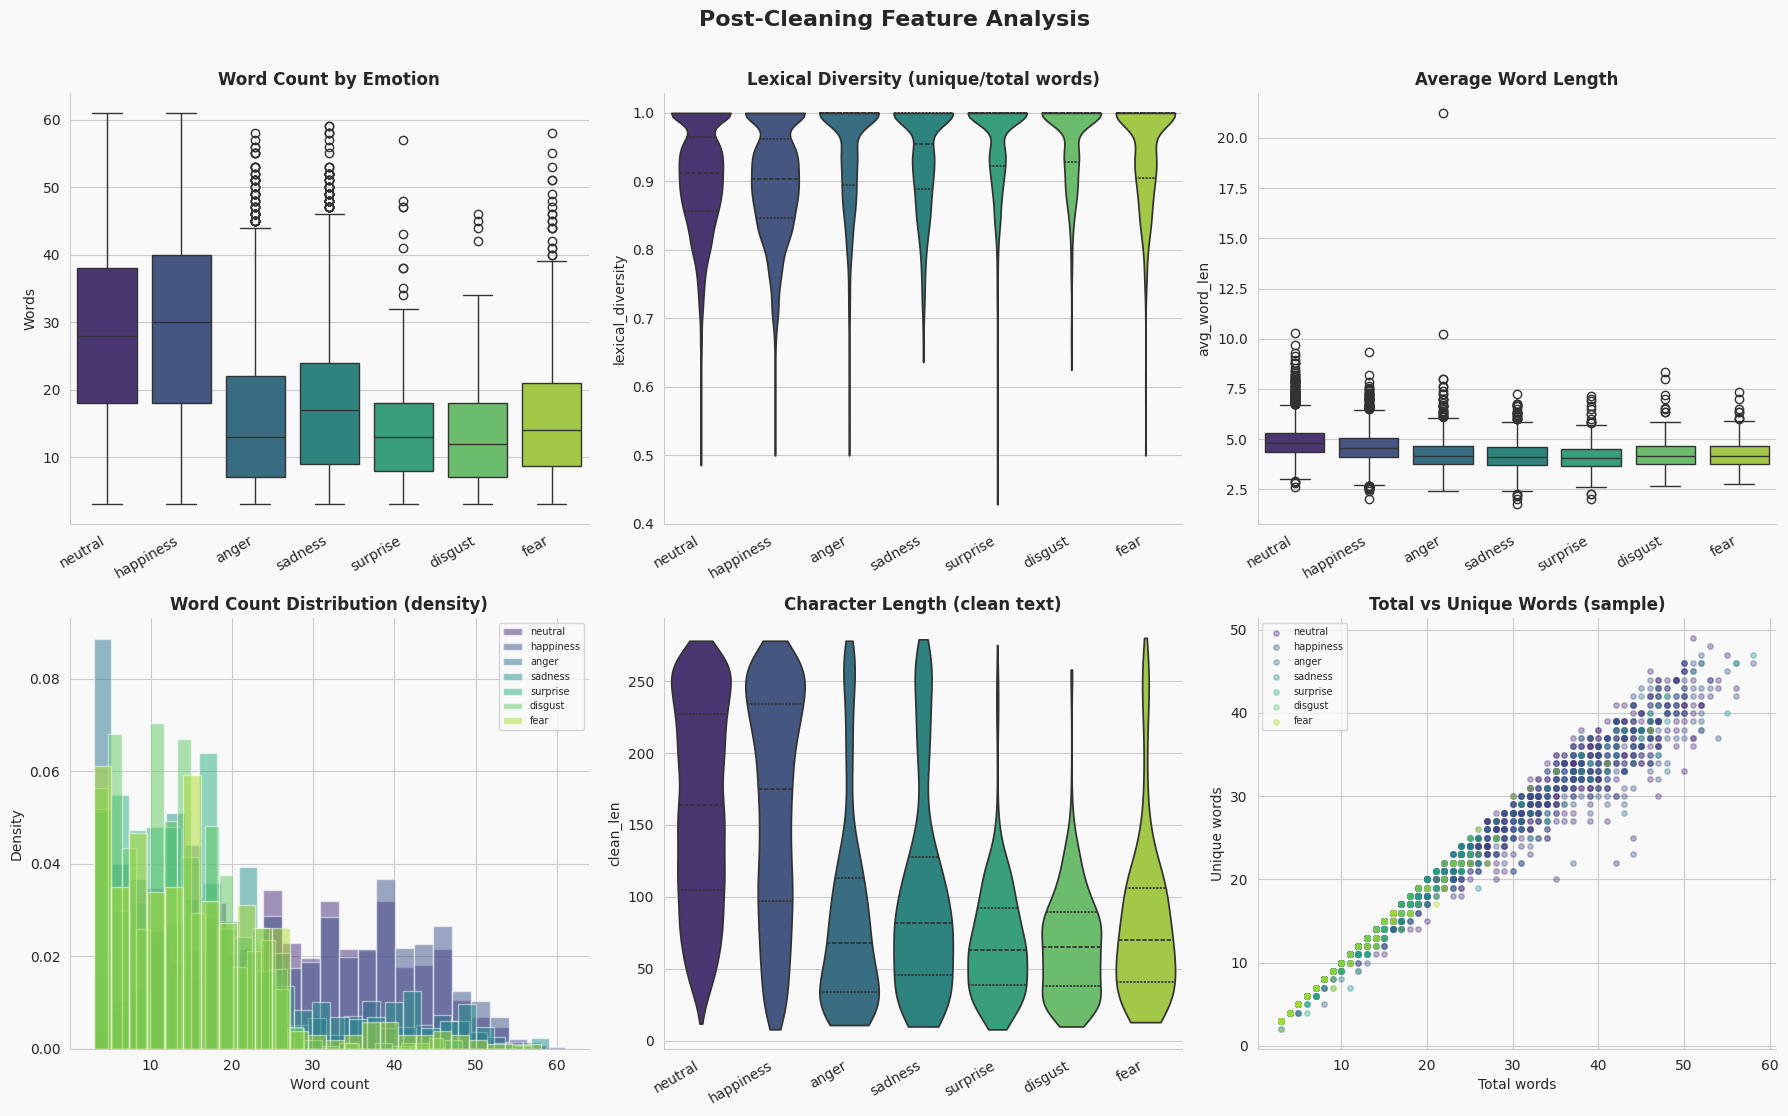


  DESCRIPTIVE STATS BY EMOTION (clean text)


word_count                unique_words                 \
                mean median     std         mean median     std   
emotion                                                           
anger         16.453   13.0  12.314       14.947   13.0  10.325   
disgust       13.149   12.0   7.033       12.386   12.0   6.211   
fear          15.996   14.0  10.236       14.731   14.0   8.699   
happiness     29.121   30.0  13.480       25.460   27.0  10.933   
neutral       28.162   28.0  12.276       24.883   25.0   9.979   
sadness       19.188   17.0  12.712       17.318   15.5  10.457   
surprise      13.631   13.0   7.369       12.844   12.0   6.504   

          lexical_diversity               avg_word_len                
                       mean median    std         mean median    std  
emotion                                                               
anger                 0.943  1.000  0.077        4.268  4.167  0.944  
disgust               0.959  1.000  0.062        4.266  4.167  0.723  
fear                  0.945  1.000  0.071        4.238  4.154  0.693  
happiness             0.898  0.903  0.081        4.595  4.550  0.757  
neutral               0.904  0.912  0.079        4.902  4.800  0.790  
sadness               0.936  0.955  0.076        4.179  4.125  0.737  
surprise              0.958  1.000  0.063        4.112  4.077  0.682

In [22]:

# ================================================================
# 6.  POST-CLEANING EDA
# ================================================================

# ── 6-A  Before / After cleaning comparison ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Before vs After Cleaning — Class Distribution",
             fontsize=14, fontweight="bold")

for ax, frame, title in zip(
    axes,
    [df_raw, df],
    ["Before Cleaning", "After Cleaning"],
):
    vc2 = frame['emotion'].value_counts()
    ax.bar(vc2.index, vc2.values,
           color=sns.color_palette(PALETTE, len(vc2)), alpha=0.9, edgecolor='white')
    ax.set_title(f"{title}  (n={len(frame):,})", fontweight="bold")
    ax.set_ylabel("Count"); ax.set_xlabel("Emotion")
    ax.set_xticklabels(vc2.index, rotation=30, ha='right')
    for i, v in enumerate(vc2.values):
        ax.text(i, v + 15, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("eda_before_after.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 6-B  Feature distributions (clean) ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Post-Cleaning Feature Analysis", fontsize=16, fontweight="bold", y=1.01)

order = df['emotion'].value_counts().index.tolist()
pal   = sns.color_palette(PALETTE, len(order))

# Word count boxplot
ax = axes[0, 0]
sns.boxplot(data=df, x='emotion', y='word_count', order=order, palette=PALETTE, ax=ax)
ax.set_title("Word Count by Emotion", fontweight="bold")
ax.set_xticklabels(order, rotation=30, ha='right'); ax.set_xlabel(""); ax.set_ylabel("Words")

# Lexical diversity
ax = axes[0, 1]
sns.violinplot(data=df, x='emotion', y='lexical_diversity', order=order,
               palette=PALETTE, inner='quartile', cut=0, ax=ax)
ax.set_title("Lexical Diversity (unique/total words)", fontweight="bold")
ax.set_xticklabels(order, rotation=30, ha='right'); ax.set_xlabel("")

# Average word length
ax = axes[0, 2]
sns.boxplot(data=df, x='emotion', y='avg_word_len', order=order, palette=PALETTE, ax=ax)
ax.set_title("Average Word Length", fontweight="bold")
ax.set_xticklabels(order, rotation=30, ha='right'); ax.set_xlabel("")

# Word count histogram overlay per emotion
ax = axes[1, 0]
for emo, color in zip(order, pal):
    subset = df[df['emotion'] == emo]['word_count']
    ax.hist(subset, bins=25, alpha=0.5, label=emo, density=True, color=color)
ax.set_title("Word Count Distribution (density)", fontweight="bold")
ax.set_xlabel("Word count"); ax.set_ylabel("Density"); ax.legend(fontsize=7)

# Clean text length violin
ax = axes[1, 1]
sns.violinplot(data=df, x='emotion', y='clean_len', order=order,
               palette=PALETTE, inner='quartile', cut=0, ax=ax)
ax.set_title("Character Length (clean text)", fontweight="bold")
ax.set_xticklabels(order, rotation=30, ha='right'); ax.set_xlabel("")

# Unique words scatter (sample)
ax = axes[1, 2]
sample = df.sample(min(2000, len(df)), random_state=42)
for emo, color in zip(order, pal):
    s = sample[sample['emotion'] == emo]
    ax.scatter(s['word_count'], s['unique_words'],
               alpha=0.35, s=15, label=emo, color=color)
ax.set_title("Total vs Unique Words (sample)", fontweight="bold")
ax.set_xlabel("Total words"); ax.set_ylabel("Unique words"); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("eda_post_cleaning_features.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 6-C  Descriptive stats table ─────────────────────────────
print("\n" + "=" * 60)
print("  DESCRIPTIVE STATS BY EMOTION (clean text)")
print("=" * 60)
stats_cols = ['word_count', 'unique_words', 'lexical_diversity', 'avg_word_len']
desc = df.groupby('emotion')[stats_cols].agg(['mean', 'median', 'std']).round(3)
display(desc)



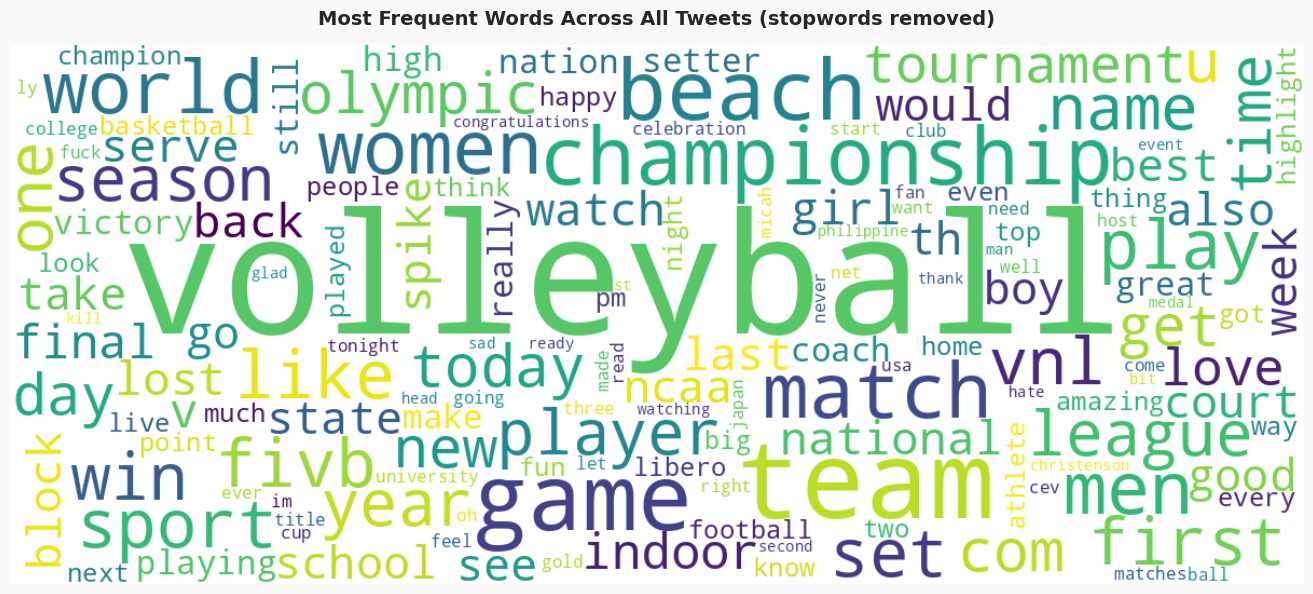

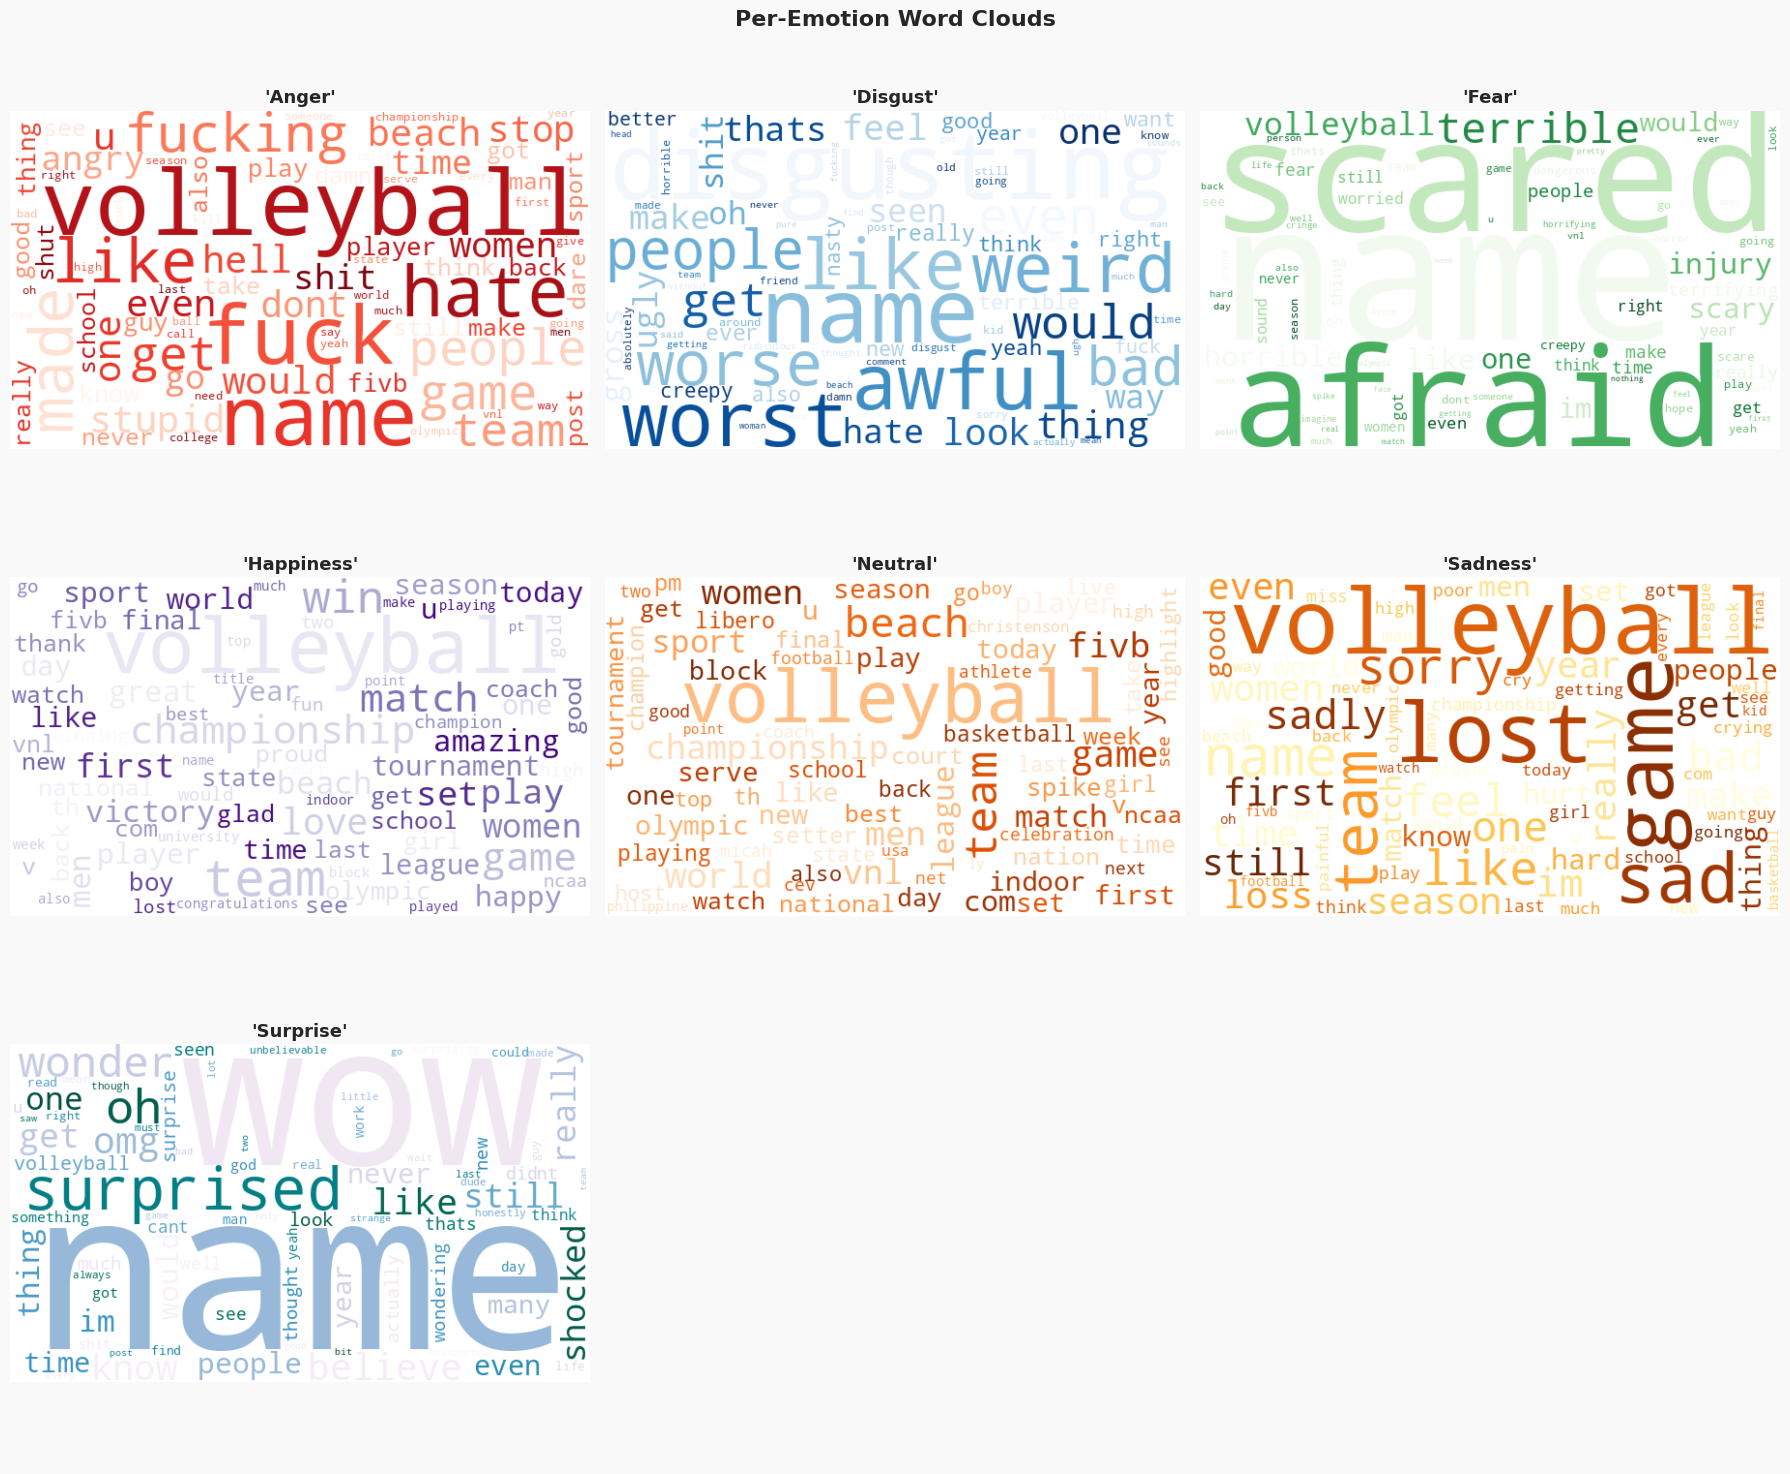

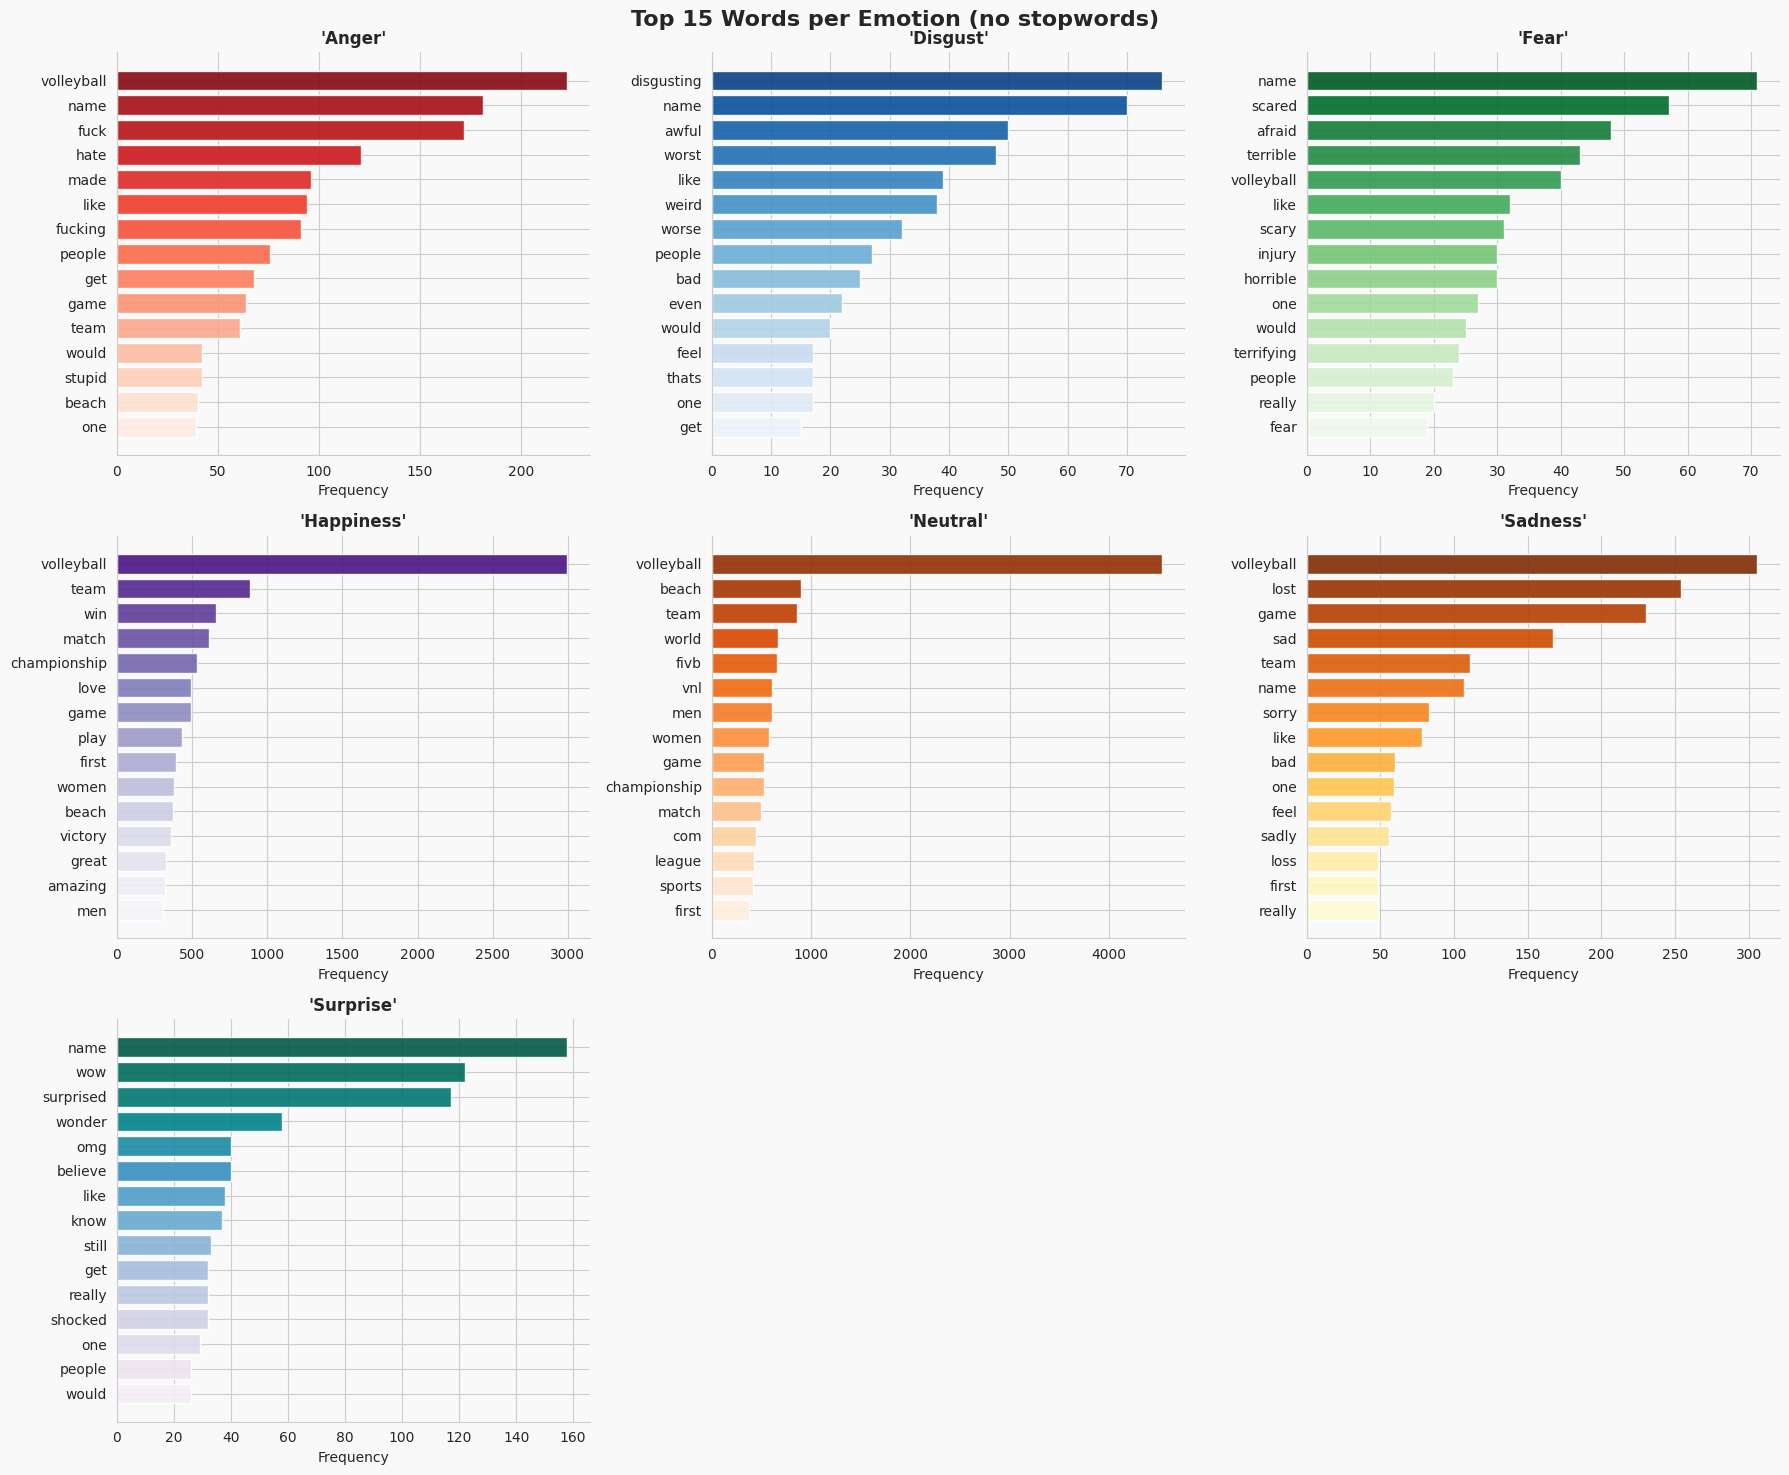


Top 20 words overall (no stopwords):


,word,count,% of tweets
0,volleyball,8137,62.82
1,team,1942,14.99
2,beach,1345,10.38
3,game,1336,10.32
4,match,1167,9.01
5,championship,1114,8.60
6,women,1061,8.19
7,world,1043,8.05
8,men,982,7.58
9,fivb,882,6.81


In [23]:

# ================================================================
# 7.  WORD FREQUENCY ANALYSIS
# ================================================================

# ── 7-A  Global word cloud ────────────────────────────────────
all_text_ns = ' '.join(df['text_no_stop'])
wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    colormap='viridis',
    max_words=150,
    stopwords=STOP_EN,
    collocations=False,
).generate(all_text_ns)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words Across All Tweets (stopwords removed)",
          fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("wordcloud_all.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 7-B  Per-emotion word clouds (grid) ──────────────────────
emotions = sorted(df['emotion'].unique())
n_emo = len(emotions)
ncols = 3
nrows = (n_emo + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
fig.suptitle("Per-Emotion Word Clouds", fontsize=16, fontweight="bold")
axes_flat = axes.flatten() if nrows > 1 else axes

cmap_list = ['Reds', 'Blues', 'Greens', 'Purples', 'Oranges', 'YlOrBr', 'PuBuGn']
for i, emo in enumerate(emotions):
    texts = ' '.join(df[df['emotion'] == emo]['text_no_stop'])
    wc_emo = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=cmap_list[i % len(cmap_list)],
        max_words=80,
        stopwords=STOP_EN,
        collocations=False,
    ).generate(texts)
    axes_flat[i].imshow(wc_emo, interpolation='bilinear')
    axes_flat[i].axis('off')
    axes_flat[i].set_title(f"'{emo.capitalize()}'", fontsize=13, fontweight="bold")

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("wordcloud_per_emotion.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 7-C  Top-15 words per emotion (bar charts) ───────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
fig.suptitle("Top 15 Words per Emotion (no stopwords)",
             fontsize=16, fontweight="bold")
axes_flat = axes.flatten() if nrows > 1 else axes

for i, emo in enumerate(emotions):
    texts = ' '.join(df[df['emotion'] == emo]['text_no_stop'])
    words = [w for w in texts.split() if len(w) > 2]
    top   = Counter(words).most_common(15)
    if not top:
        continue
    words_top, counts_top = zip(*top)
    color = sns.color_palette(cmap_list[i % len(cmap_list)] + '_r', 15)
    axes_flat[i].barh(list(reversed(words_top)), list(reversed(counts_top)),
                      color=list(reversed(color)), alpha=0.9)
    axes_flat[i].set_title(f"'{emo.capitalize()}'", fontweight="bold")
    axes_flat[i].set_xlabel("Frequency")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig("top_words_per_emotion.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 7-D  Word frequency table (top 20 overall) ───────────────
all_words_ns = [w for w in all_text_ns.split() if len(w) > 2]
freq_df = pd.DataFrame(Counter(all_words_ns).most_common(20),
                       columns=['word', 'count'])
freq_df['% of tweets'] = (freq_df['count'] / len(df) * 100).round(2)
print("\nTop 20 words overall (no stopwords):")
display(freq_df)


  CLASS IMBALANCE REPORT


,Count,Percent,Ratio to min
emotion,,,
neutral,5083,39.24,10.86
happiness,3847,29.70,8.22
anger,1225,9.46,2.62
sadness,1110,8.57,2.37
surprise,724,5.59,1.55
disgust,495,3.82,1.06
fear,468,3.61,1.00



Max/Min class ratio  : 10.86x
⚠  Significant class imbalance detected (>3x). Consider:
   • Weighted loss in training (class_weight='balanced')
   • Stratified train/val split (already applied)
   • Oversampling minority classes (e.g. SMOTE on embeddings)


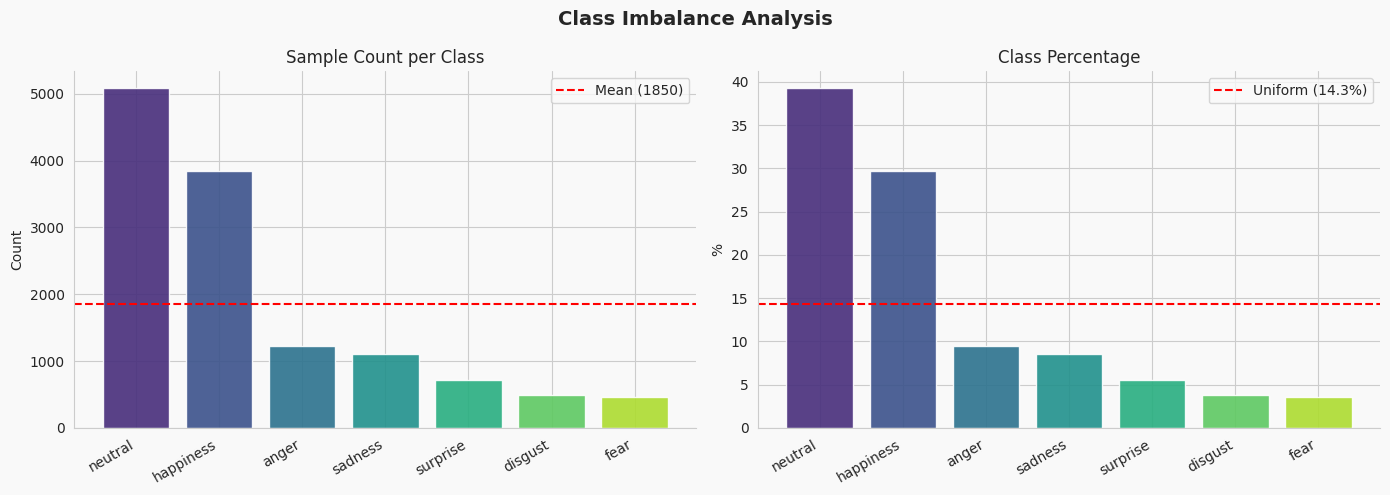

In [24]:


# ================================================================
# 8.  CLASS IMBALANCE ANALYSIS
# ================================================================

class_counts = df['emotion'].value_counts()
class_pct    = df['emotion'].value_counts(normalize=True) * 100
imbalance_ratio = class_counts.max() / class_counts.min()

print("\n" + "=" * 55)
print("  CLASS IMBALANCE REPORT")
print("=" * 55)
imbalance_df = pd.DataFrame({
    'Count':   class_counts,
    'Percent': class_pct.round(2),
})
imbalance_df['Ratio to min'] = (imbalance_df['Count'] / imbalance_df['Count'].min()).round(2)
display(imbalance_df)
print(f"\nMax/Min class ratio  : {imbalance_ratio:.2f}x")
if imbalance_ratio > 3:
    print("⚠  Significant class imbalance detected (>3x). Consider:")
    print("   • Weighted loss in training (class_weight='balanced')")
    print("   • Stratified train/val split (already applied)")
    print("   • Oversampling minority classes (e.g. SMOTE on embeddings)")
else:
    print("✓  Class imbalance is moderate.")

# Imbalance visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Imbalance Analysis", fontsize=14, fontweight="bold")

colors = sns.color_palette(PALETTE, len(class_counts))

ax = axes[0]
ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', alpha=0.9)
ax.axhline(class_counts.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean ({class_counts.mean():.0f})')
ax.set_title("Sample Count per Class"); ax.set_ylabel("Count")
ax.set_xticklabels(class_counts.index, rotation=30, ha='right')
ax.legend()

ax = axes[1]
ax.bar(class_pct.index, class_pct.values, color=colors, edgecolor='white', alpha=0.9)
ax.axhline(100 / len(class_pct), color='red', linestyle='--', linewidth=1.5,
           label=f'Uniform ({100/len(class_pct):.1f}%)')
ax.set_title("Class Percentage"); ax.set_ylabel("%")
ax.set_xticklabels(class_pct.index, rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

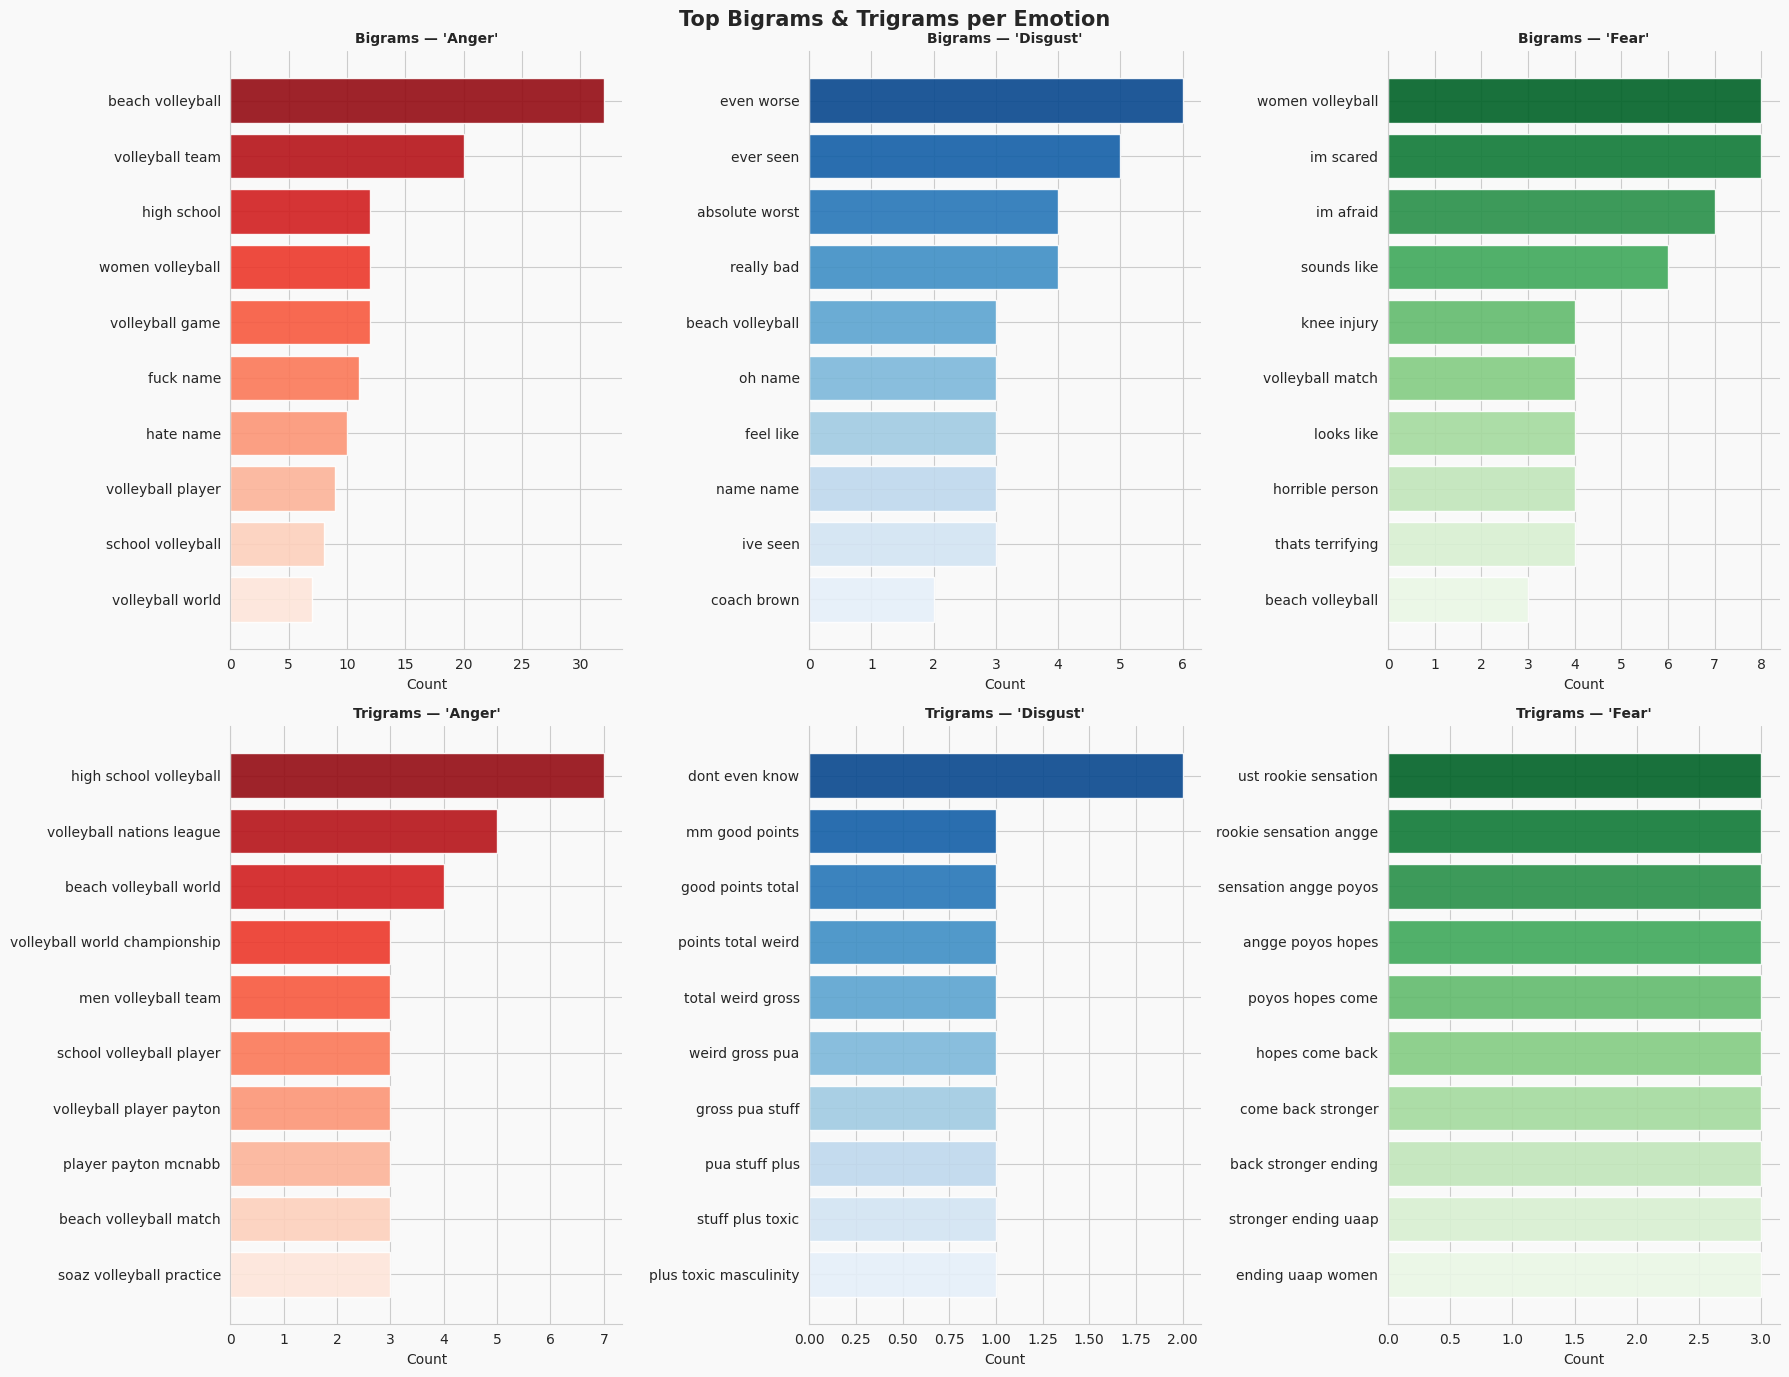

In [25]:


# ================================================================
# 9.  N-GRAM ANALYSIS  (bigrams & trigrams)
# ================================================================

def get_ngrams(texts, n, top_k=15):
    """Extract top_k most common n-grams from a list of texts."""
    tokens_list = [t.split() for t in texts]
    ngrams = []
    for tokens in tokens_list:
        ngrams.extend(zip(*[tokens[i:] for i in range(n)]))
    ngram_str = [' '.join(g) for g in ngrams]
    return Counter(ngram_str).most_common(top_k)

fig, axes = plt.subplots(2, ncols, figsize=(18, nrows * 4 + 2))
fig.suptitle("Top Bigrams & Trigrams per Emotion", fontsize=15, fontweight="bold")

for col_idx, emo in enumerate(emotions[:ncols]):
    texts_emo = df[df['emotion'] == emo]['text_no_stop'].tolist()
    for row_idx, (n, label) in enumerate([(2, 'Bigrams'), (3, 'Trigrams')]):
        top = get_ngrams(texts_emo, n, 10)
        if not top: continue
        phrases, counts = zip(*top)
        ax = axes[row_idx][col_idx]
        ax.barh(list(reversed(phrases)), list(reversed(counts)),
                color=sns.color_palette(cmap_list[col_idx % len(cmap_list)], 10),
                alpha=0.9)
        ax.set_title(f"{label} — '{emo.capitalize()}'", fontweight="bold", fontsize=10)
        ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig("ngrams_per_emotion.png", dpi=150, bbox_inches="tight")
plt.show()

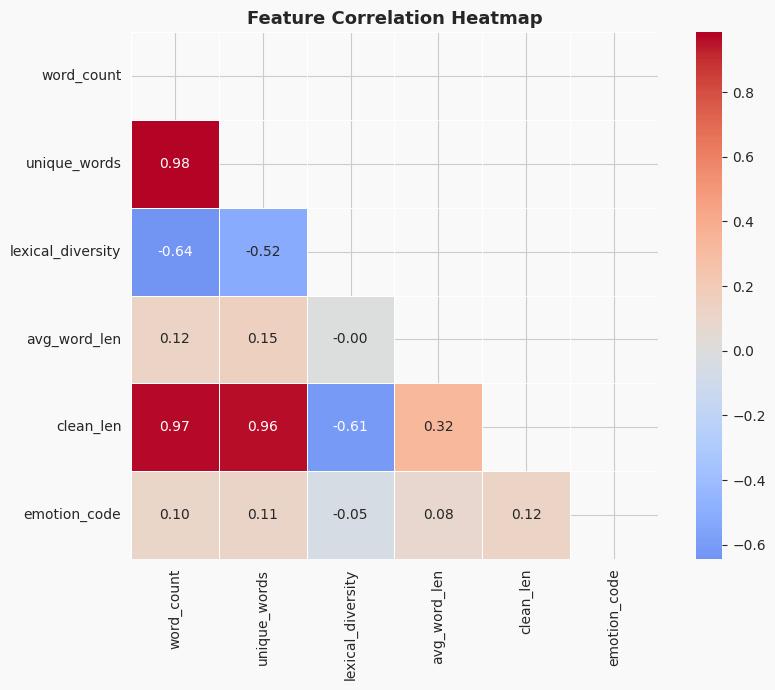

In [26]:

# ================================================================
# 10.  CORRELATION / FEATURE HEATMAP
# ================================================================

le = LabelEncoder()
df['emotion_code'] = le.fit_transform(df['emotion'])

feat_corr = df[['word_count', 'unique_words', 'lexical_diversity',
                'avg_word_len', 'clean_len', 'emotion_code']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.6,
    square=True, ax=ax,
)
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [27]:

# ================================================================
# 11.  FINAL DATASET SUMMARY
# ================================================================

print("\n" + "=" * 60)
print("  FINAL DATASET SUMMARY")
print("=" * 60)

summary = {
    "Rows after cleaning":    len(df),
    "Unique emotion classes":  df['emotion'].nunique(),
    "Emotion classes":         ', '.join(sorted(df['emotion'].unique())),
    "Avg word count":          f"{df['word_count'].mean():.1f}",
    "Median word count":       f"{df['word_count'].median():.1f}",
    "Avg lexical diversity":   f"{df['lexical_diversity'].mean():.3f}",
    "Avg word length":         f"{df['avg_word_len'].mean():.2f}",
    "Class imbalance ratio":   f"{imbalance_ratio:.2f}x",
}
for k, v in summary.items():
    print(f"  {k:<30} {v}")

print("\nClass distribution (final):")
print(df['emotion'].value_counts().to_string())

print("\n✓  Saved artefacts:")
for f in [
    "eda_raw_overview.png",
    "eda_before_after.png",
    "eda_post_cleaning_features.png",
    "wordcloud_all.png",
    "wordcloud_per_emotion.png",
    "top_words_per_emotion.png",
    "class_imbalance.png",
    "ngrams_per_emotion.png",
    "feature_correlation.png",
]:
    print(f"   {f}")

print("\n✓  Ready columns:")
print("   df['clean_text']   → for BERT / RoBERTa tokenisation")
print("   df['text_no_stop'] → for TF-IDF / Logistic Regression")
print("   df['emotion']      → raw label (string)")
print("   df['emotion_code'] → encoded label (int)")


  FINAL DATASET SUMMARY
  Rows after cleaning            12952
  Unique emotion classes         7
  Emotion classes                anger, disgust, fear, happiness, neutral, sadness, surprise
  Avg word count                 24.7
  Median word count              23.0
  Avg lexical diversity          0.915
  Avg word length                4.60
  Class imbalance ratio          10.86x

Class distribution (final):
emotion
neutral      5083
happiness    3847
anger        1225
sadness      1110
surprise      724
disgust       495
fear          468

✓  Saved artefacts:
   eda_raw_overview.png
   eda_before_after.png
   eda_post_cleaning_features.png
   wordcloud_all.png
   wordcloud_per_emotion.png
   top_words_per_emotion.png
   class_imbalance.png
   ngrams_per_emotion.png
   feature_correlation.png

✓  Ready columns:
   df['clean_text']   → for BERT / RoBERTa tokenisation
   df['text_no_stop'] → for TF-IDF / Logistic Regression
   df['emotion']      → raw label (string)
   df['emotion_code

# 4. Model Learning

In [25]:

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["clean_text"], padding=True, truncation=True)

dataset = Dataset.from_pandas(df)

dataset = dataset.map(tokenize, batched=True)

dataset = dataset.train_test_split(test_size=0.2)
data_collator = DataCollatorWithPadding(tokenizer)

Map:   0%|          | 0/13044 [00:00<?, ? examples/s]

In [27]:


df_bert = df[['clean_text', 'emotion']].copy()
# Кодируем метки
label_encoder = LabelEncoder()
df_bert["label"] = label_encoder.fit_transform(df_bert["emotion"])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)
## 4. Разделение на train / validation
train_df, val_df = train_test_split(
    df_bert,
    test_size=0.1,
    stratify=df_bert["label"],
    random_state=42
)

['anger' 'disgust' 'fear' 'happiness' 'neutral' 'sadness' 'surprise']


In [28]:
 ## 5. Конвертация в HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["clean_text", "label"]])

In [29]:
## 6. Токенизация
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/11739 [00:00<?, ? examples/s]

Map:   0%|          | 0/1305 [00:00<?, ? examples/s]

In [30]:
## 7. Модель BERT
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [31]:

## 8. Метрики оценки
def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [32]:

## 9. Настройки обучения
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,

    eval_strategy="epoch",   # иногда evaluation_strategy, но у тебя работает eval_strategy
    save_strategy="epoch",

    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [33]:
## 10.1 Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=7
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
## 10.2 Metrics (F1 + Accuracy)
# pip install evaluate
import numpy as np
import evaluate

# accuracy = evaluate.load("accuracy")
# f1 = evaluate.load("f1")

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)

#     return {
#         "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
#         "f1": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"]
#     }

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1_weighted": f1.compute(predictions=predictions, references=labels, average="weighted")["f1"],
        "f1_macro": f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    }

In [38]:
# 10.3 Trainer
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [39]:

# pip install numpy==1.26.4
import numpy as np
print(np.__version__)
import torch

2.0.2


In [40]:

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
df.emotion.value_counts()
import torch
print(torch.cuda.is_available())

True
Tesla T4
True


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.794285,0.445066,0.875862,0.875534,0.806918
2,0.389148,0.421159,0.890421,0.888959,0.827900
3,0.209532,0.459410,0.892720,0.891942,0.824607
4,0.173473,0.474762,0.898851,0.897825,0.830721


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluation history:
   epoch  eval_loss  eval_accuracy  eval_f1_weighted  eval_f1_macro
1    1.0     0.4451         0.8759            0.8755         0.8069
3    2.0     0.4212         0.8904            0.8890         0.8279
6    3.0     0.4594         0.8927            0.8919         0.8246
8    4.0     0.4748         0.8989            0.8978         0.8307


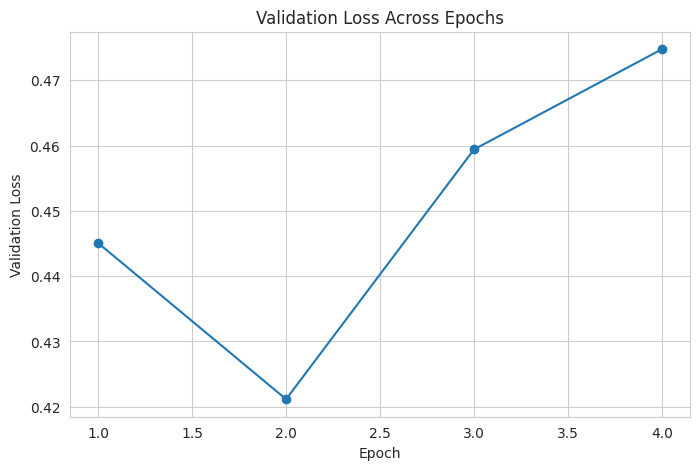

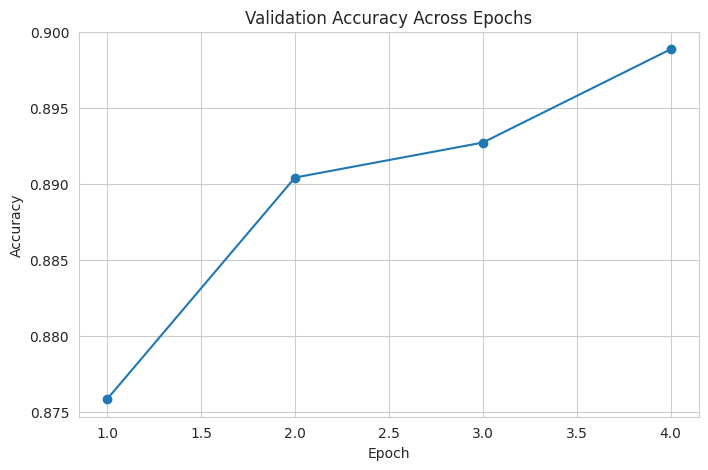

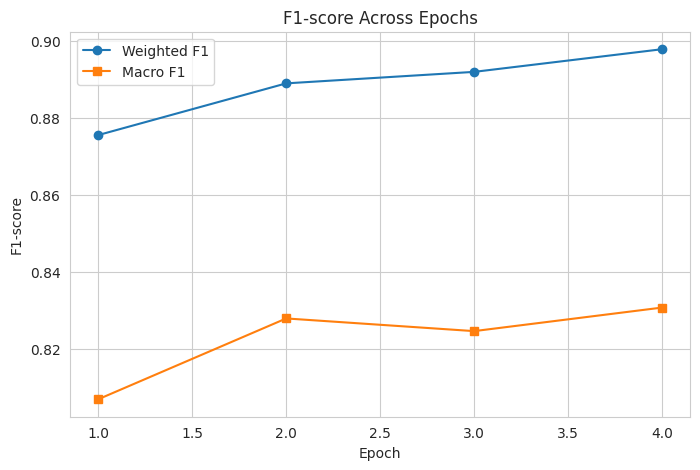

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Train the model
trainer.train()

# Extract training history
logs = trainer.state.log_history

# Convert logs to DataFrame
history = pd.DataFrame(logs)

# Keep only rows with evaluation metrics
eval_history = history[history["eval_loss"].notnull()].copy()

# Display metrics table (with both F1 variants)
print("\nEvaluation history:")
cols_to_show = ["epoch", "eval_loss", "eval_accuracy"]
if "eval_f1_weighted" in eval_history.columns:
    cols_to_show.append("eval_f1_weighted")
if "eval_f1_macro" in eval_history.columns:
    cols_to_show.append("eval_f1_macro")
# fallback to old "eval_f1" if present
if "eval_f1" in eval_history.columns and "eval_f1_weighted" not in eval_history.columns:
    cols_to_show.append("eval_f1")

print(eval_history[cols_to_show].round(4))

# -----------------------------
# Validation Loss Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(eval_history["epoch"], eval_history["eval_loss"], marker='o')
plt.title("Validation Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

# -----------------------------
# Accuracy Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(eval_history["epoch"], eval_history["eval_accuracy"], marker='o')
plt.title("Validation Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# -----------------------------
# F1-score Plots (Weighted & Macro)
# -----------------------------
plt.figure(figsize=(8,5))

if "eval_f1_weighted" in eval_history.columns:
    plt.plot(eval_history["epoch"], eval_history["eval_f1_weighted"], marker='o', label="Weighted F1")
if "eval_f1_macro" in eval_history.columns:
    plt.plot(eval_history["epoch"], eval_history["eval_f1_macro"], marker='s', label="Macro F1")
if "eval_f1" in eval_history.columns and "eval_f1_weighted" not in eval_history.columns:
    # fallback to old single F1
    plt.plot(eval_history["epoch"], eval_history["eval_f1"], marker='o', label="F1 (weighted)")

plt.title("F1-score Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

# 2. RoBERTa + Multi-Head Attention  —  Emotion Classification

In [70]:
# ============================================================
# RoBERTa + Multi-Head Attention  —  Emotion Classification
# Diploma work: LR vs BERT vs RoBERTa comparison
# ============================================================

# ── 0. Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    PreTrainedModel,
    RobertaConfig,
)
from transformers.modeling_outputs import SequenceClassifierOutput
import evaluate


In [78]:

# ── 1. Reproducibility ────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


# # ================================================================
# # 2. ARCHITECTURE: RoBERTa + Custom Multi-Head Attention Pooling
# # ================================================================
# #
# #  [Input tokens]
# #       ↓
# #  RoBERTa encoder  →  hidden states  (batch, seq_len, hidden_dim)
# #       ↓
# #  Multi-Head Attention Pooling        ← key addition vs plain BERT
# #  (learnable query attends over all token representations)
# #       ↓
# #  context vector  (batch, hidden_dim)
# #       ↓
# #  LayerNorm → Dropout → Linear → num_classes
# # ================================================================

class MultiHeadAttentionPooling(nn.Module):
    """
    Applies multi-head self-attention to the full sequence of
    RoBERTa hidden states, then produces a single context vector
    via weighted sum (instead of just taking the [CLS] token).

    Args:
        hidden_dim  – RoBERTa hidden size (768 for base)
        num_heads   – number of attention heads
        dropout     – dropout probability on attention weights
    """
    def __init__(self, hidden_dim: int = 768, num_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert hidden_dim % num_heads == 0, "hidden_dim must be divisible by num_heads"

        self.num_heads  = num_heads
        self.head_dim   = hidden_dim // num_heads
        self.hidden_dim = hidden_dim
        self.scale      = self.head_dim ** -0.5

        # Learnable query: one vector per head, projected into key/value space
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key   = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)
        self.out   = nn.Linear(hidden_dim, hidden_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.norm         = nn.LayerNorm(hidden_dim)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, S, H) → (B, heads, S, head_dim)"""
        B, S, H = x.shape
        x = x.view(B, S, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def forward(
        self,
        hidden_states: torch.Tensor,        # (B, seq_len, hidden_dim)
        attention_mask: torch.Tensor = None  # (B, seq_len)  0/1
    ) -> torch.Tensor:
        B, S, H = hidden_states.shape

        Q = self._split_heads(self.query(hidden_states))  # (B, heads, S, d)
        K = self._split_heads(self.key(hidden_states))
        V = self._split_heads(self.value(hidden_states))

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, heads, S, S)

        # Mask padding tokens (set their logits to -inf before softmax)
        if attention_mask is not None:
            # attention_mask: (B, S) → (B, 1, 1, S) for broadcasting
            mask = (1.0 - attention_mask.float()).unsqueeze(1).unsqueeze(2) * -1e9
            scores = scores + mask

        attn_weights = torch.softmax(scores, dim=-1)      # (B, heads, S, S)
        attn_weights = self.attn_dropout(attn_weights)

        context = torch.matmul(attn_weights, V)           # (B, heads, S, d)
        context = context.transpose(1, 2).contiguous()    # (B, S, H)
        context = context.view(B, S, H)
        context = self.out(context)                       # (B, S, H)

        # Pool: mean over sequence dimension (weighted by attention mask)
        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).float()
            pooled = (context * mask_expanded).sum(1) / mask_expanded.sum(1).clamp(min=1e-9)
        else:
            pooled = context.mean(dim=1)                  # (B, H)

        pooled = self.norm(pooled)                        # residual-free LN for stability
        return pooled                                     # (B, hidden_dim)


# class RobertaMultiAttentionClassifier(PreTrainedModel):
#     """
#     Full model:
#         RoBERTa-base  →  MultiHeadAttentionPooling  →  classifier head
#     Registered as a HuggingFace PreTrainedModel so it integrates
#     seamlessly with Trainer.
#     """
#     config_class = RobertaConfig

#     def __init__(self, config: RobertaConfig, num_labels: int,
#                  num_heads: int = 8, attn_dropout: float = 0.1,
#                  cls_dropout: float = 0.2):
#         super().__init__(config)
#         self.num_labels = num_labels

#         # RoBERTa backbone
#         self.roberta = RobertaModel(config, add_pooling_layer=False)

#         hidden_dim = config.hidden_size  # 768 for roberta-base

#         # Custom multi-head attention pooling
#         self.attention_pooling = MultiHeadAttentionPooling(
#             hidden_dim=hidden_dim,
#             num_heads=num_heads,
#             dropout=attn_dropout,
#         )

#         # Classification head
#         self.classifier = nn.Sequential(
#             nn.Dropout(cls_dropout),
#             nn.Linear(hidden_dim, hidden_dim // 2),
#             nn.GELU(),
#             nn.LayerNorm(hidden_dim // 2),
#             nn.Dropout(cls_dropout / 2),
#             nn.Linear(hidden_dim // 2, num_labels),
#         )

#         # Weight initialisation
#         self.post_init()

#     def forward(
#         self,
#         input_ids=None,
#         attention_mask=None,
#         token_type_ids=None,
#         labels=None,
#         **kwargs,
#     ) -> SequenceClassifierOutput:

#         outputs = self.roberta(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#         )

#         # outputs.last_hidden_state → (B, seq_len, 768)
#         pooled = self.attention_pooling(
#             outputs.last_hidden_state,
#             attention_mask=attention_mask,
#         )

#         logits = self.classifier(pooled)  # (B, num_labels)

#         loss = None
#         if labels is not None:
#             loss_fn = nn.CrossEntropyLoss()
#             loss = loss_fn(logits, labels)

#         return SequenceClassifierOutput(
#             loss=loss,
#             logits=logits,
#             hidden_states=outputs.hidden_states,
#             attentions=outputs.attentions,
#         )


Device: cuda


In [79]:
# ================================================================
# 2. ARCHITECTURE  —  новая версия: nn.Module вместо PreTrainedModel
# ================================================================

class RobertaMultiAttentionClassifier(nn.Module):          # ← nn.Module, не PreTrainedModel
    def __init__(self, config, num_labels: int,
                 num_heads: int = 8, attn_dropout: float = 0.1,
                 cls_dropout: float = 0.2):
        super().__init__()
        self.num_labels = num_labels

        self.roberta = RobertaModel(config, add_pooling_layer=False)

        hidden_dim = config.hidden_size  # 768

        self.attention_pooling = MultiHeadAttentionPooling(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
        )

        self.classifier = nn.Sequential(
            nn.Dropout(cls_dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.LayerNorm(hidden_dim // 2),
            nn.Dropout(cls_dropout / 2),
            nn.Linear(hidden_dim // 2, num_labels),
        )

    def forward(self, input_ids=None, attention_mask=None,
                token_type_ids=None, labels=None, **kwargs):

        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        pooled = self.attention_pooling(
            outputs.last_hidden_state,
            attention_mask=attention_mask,
        )

        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
        )

In [80]:

# ── 3. Data preparation ───────────────────────────────────────
# NOTE: df must already be loaded and cleaned (column "clean_text", "emotion")
# ─────────────────────────────────────────────────────────────
# Uncomment below if you need to reload df:
# df = pd.read_csv("your_data.csv")

df_roberta = df[["clean_text", "emotion"]].copy()

label_encoder_roberta = LabelEncoder()
df_roberta["label"] = label_encoder_roberta.fit_transform(df_roberta["emotion"])

NUM_LABELS = len(label_encoder_roberta.classes_)
LABEL_NAMES = list(label_encoder_roberta.classes_)
print(f"Classes ({NUM_LABELS}): {LABEL_NAMES}")

train_df_r, val_df_r = train_test_split(
    df_roberta,
    test_size=0.1,
    stratify=df_roberta["label"],
    random_state=SEED,
)
print(f"Train: {len(train_df_r)} | Val: {len(val_df_r)}")

Classes (7): ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
Train: 11739 | Val: 1305


In [81]:

# ── 4. Tokenisation ───────────────────────────────────────────
MODEL_NAME = "roberta-base"
tokenizer_roberta = RobertaTokenizer.from_pretrained(MODEL_NAME)

train_dataset_r = Dataset.from_pandas(train_df_r[["clean_text", "label"]])
val_dataset_r   = Dataset.from_pandas(val_df_r[["clean_text", "label"]])

def tokenize_roberta(example):
    return tokenizer_roberta(
        example["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

train_dataset_r = train_dataset_r.map(tokenize_roberta, batched=True)
val_dataset_r   = val_dataset_r.map(tokenize_roberta,   batched=True)

train_dataset_r.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset_r.set_format(  type="torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/11739 [00:00<?, ? examples/s]

Map:   0%|          | 0/1305 [00:00<?, ? examples/s]

In [82]:
from transformers import RobertaForSequenceClassification

roberta_model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [84]:
# # ── 5. Model instantiation ────────────────────────────────────
roberta_config = RobertaConfig.from_pretrained(MODEL_NAME)

roberta_model = RobertaMultiAttentionClassifier(
    config=roberta_config,
    num_labels=NUM_LABELS,
    num_heads=8,
    attn_dropout=0.1,
    cls_dropout=0.2,
)

# ВАЖНО: add_pooling_layer=False
pretrained = RobertaModel.from_pretrained(
    MODEL_NAME,
    add_pooling_layer=False
)

roberta_model.roberta.load_state_dict(pretrained.state_dict())

del pretrained

roberta_model = roberta_model.to(DEVICE)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [87]:
# ── 6. Metrics ────────────────────────────────────────────────
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics_roberta(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"],
        "f1_weighted": f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"],
        "f1_macro":    f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"],
    }


In [85]:


# ── 7. Training arguments ─────────────────────────────────────
training_args_roberta = TrainingArguments(
    output_dir="./results_roberta",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_ratio=0.1,                    # linear warmup for first 10% steps

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_dir="./logs_roberta",
    logging_steps=20,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),      # mixed precision if GPU is available
    seed=SEED,
)

data_collator_roberta = DataCollatorWithPadding(tokenizer=tokenizer_roberta)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:

# ── 8. Trainer ────────────────────────────────────────────────
trainer_roberta = Trainer(
    model=roberta_model,
    args=training_args_roberta,
    train_dataset=train_dataset_r,
    eval_dataset=val_dataset_r,
    data_collator=data_collator_roberta,
    compute_metrics=compute_metrics_roberta,
)

# ── 9. Train ──────────────────────────────────────────────────
trainer_roberta.train()

# ── 10. Extract training history ─────────────────────────────
logs_roberta   = trainer_roberta.state.log_history
history_roberta = pd.DataFrame(logs_roberta)

eval_history_roberta  = history_roberta[history_roberta["eval_loss"].notnull()].copy()
train_history_roberta = history_roberta[history_roberta["loss"].notnull()].copy()

print("\n── RoBERTa Evaluation History ──")
print(eval_history_roberta[
    ["epoch", "eval_loss", "eval_accuracy", "eval_f1_weighted", "eval_f1_macro"]
].round(4).to_string(index=False))



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.423728,0.484606,0.863602,0.862849,0.795739
2,0.413312,0.476383,0.870498,0.869537,0.804717
3,0.328891,0.533821,0.878161,0.877500,0.816208


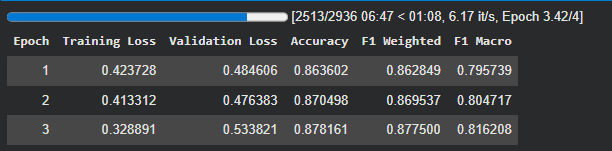

In [1]:

# ================================================================
# 11. VISUALISATION  (RoBERTa training dynamics)
# ================================================================

def plot_roberta_training(eval_hist, train_hist):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("RoBERTa + Multi-Head Attention  —  Training Dynamics",
                 fontsize=16, fontweight="bold", y=1.01)

    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    epochs = eval_hist["epoch"].values

    # ── Plot 1: Train vs Val Loss ─────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    if "loss" in train_hist.columns:
        # Group by epoch for mean train loss per epoch
        tl = train_hist.groupby("epoch")["loss"].mean().reset_index()
        ax1.plot(tl["epoch"], tl["loss"], marker="o", label="Train Loss", color="#e07b54")
    ax1.plot(epochs, eval_hist["eval_loss"], marker="s", label="Val Loss", color="#4c72b0")
    ax1.set_title("Loss Curve")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.35)

    # ── Plot 2: Accuracy ──────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, eval_hist["eval_accuracy"], marker="o", color="#55a868", linewidth=2)
    ax2.fill_between(epochs, eval_hist["eval_accuracy"], alpha=0.15, color="#55a868")
    ax2.set_title("Validation Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1); ax2.grid(alpha=0.35)

    # ── Plot 3: F1 Weighted & Macro ───────────────────────────
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(epochs, eval_hist["eval_f1_weighted"], marker="o", label="Weighted F1", color="#8172b2")
    ax3.plot(epochs, eval_hist["eval_f1_macro"],    marker="s", label="Macro F1",    color="#c44e52")
    ax3.fill_between(epochs, eval_hist["eval_f1_weighted"], alpha=0.1, color="#8172b2")
    ax3.fill_between(epochs, eval_hist["eval_f1_macro"],    alpha=0.1, color="#c44e52")
    ax3.set_title("F1-Score Across Epochs")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1-score")
    ax3.set_ylim(0, 1); ax3.legend(); ax3.grid(alpha=0.35)

    # ── Plot 4: Learning rate schedule (if logged) ────────────
    ax4 = fig.add_subplot(gs[1, 0])
    lr_rows = history_roberta[history_roberta["learning_rate"].notnull()] if "learning_rate" in history_roberta.columns else pd.DataFrame()
    if not lr_rows.empty:
        ax4.plot(lr_rows.index, lr_rows["learning_rate"], color="#dd8452")
        ax4.set_title("Learning Rate Schedule")
        ax4.set_xlabel("Step"); ax4.set_ylabel("LR")
        ax4.grid(alpha=0.35)
    else:
        ax4.text(0.5, 0.5, "LR schedule\nnot logged", ha="center", va="center",
                 transform=ax4.transAxes, fontsize=12, color="grey")
        ax4.set_title("Learning Rate Schedule")

    # ── Plot 5: Metrics comparison across epochs (bar) ────────
    ax5 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(epochs))
    w = 0.25
    ax5.bar(x - w, eval_hist["eval_accuracy"],    width=w, label="Accuracy",    color="#55a868", alpha=0.85)
    ax5.bar(x,     eval_hist["eval_f1_weighted"],  width=w, label="Weighted F1", color="#8172b2", alpha=0.85)
    ax5.bar(x + w, eval_hist["eval_f1_macro"],     width=w, label="Macro F1",    color="#c44e52", alpha=0.85)
    ax5.set_xticks(x); ax5.set_xticklabels([f"E{int(e)}" for e in epochs])
    ax5.set_title("Metric Breakdown per Epoch")
    ax5.set_ylabel("Score"); ax5.set_ylim(0, 1)
    ax5.legend(fontsize=8); ax5.grid(axis="y", alpha=0.35)

    # ── Plot 6: Best epoch highlight table ────────────────────
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis("off")
    best_idx = eval_hist["eval_f1_macro"].idxmax()
    best_row = eval_hist.loc[best_idx]
    table_data = [
        ["Metric", "Best Value", "Epoch"],
        ["Accuracy",    f"{best_row['eval_accuracy']:.4f}",    int(best_row['epoch'])],
        ["F1 Weighted", f"{best_row['eval_f1_weighted']:.4f}", int(best_row['epoch'])],
        ["F1 Macro",    f"{best_row['eval_f1_macro']:.4f}",    int(best_row['epoch'])],
        ["Val Loss",    f"{eval_hist['eval_loss'].min():.4f}",
                        int(eval_hist.loc[eval_hist['eval_loss'].idxmin(), 'epoch'])],
    ]
    tbl = ax6.table(cellText=table_data[1:], colLabels=table_data[0],
                    loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(10)
    tbl.scale(1.2, 1.8)
    # Header styling
    for j in range(3):
        tbl[(0, j)].set_facecolor("#2d6a9f")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
    ax6.set_title("Best Epoch Summary", fontweight="bold")

    plt.tight_layout()
    plt.savefig("roberta_training_dynamics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: roberta_training_dynamics.png")

plot_roberta_training(eval_history_roberta, train_history_roberta)



NameError: name 'eval_history_roberta' is not defined

In [ ]:

# ================================================================
# 12. PER-CLASS METRICS  (Classification Report)
# ================================================================

def get_roberta_predictions(trainer, dataset):
    """Returns true labels and model predictions for a dataset."""
    predictions_output = trainer.predict(dataset)
    preds  = np.argmax(predictions_output.predictions, axis=1)
    labels = predictions_output.label_ids
    return labels, preds

print("\n── Getting predictions on validation set ──")
true_labels, pred_labels = get_roberta_predictions(trainer_roberta, val_dataset_r)

# Full classification report
report = classification_report(
    true_labels, pred_labels,
    target_names=LABEL_NAMES,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
print("\nClassification Report (RoBERTa + Multi-Att):")
print(report_df.round(4))


def plot_per_class_metrics(report_df, model_name="RoBERTa + Multi-Head Attention"):
    """Bar chart of precision, recall, f1 for each class."""
    # Select only class rows (exclude avg rows)
    class_rows = report_df.loc[LABEL_NAMES, ["precision", "recall", "f1-score"]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{model_name}  —  Per-Class Metrics", fontsize=14, fontweight="bold")

    colors = {"precision": "#4c72b0", "recall": "#55a868", "f1-score": "#c44e52"}
    for ax, metric in zip(axes, ["precision", "recall", "f1-score"]):
        vals = class_rows[metric]
        bars = ax.barh(vals.index, vals.values, color=colors[metric], alpha=0.85)
        ax.set_xlim(0, 1)
        ax.set_title(metric.capitalize(), fontsize=12)
        ax.set_xlabel("Score")
        ax.grid(axis="x", alpha=0.3)
        for bar, v in zip(bars, vals.values):
            ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("roberta_per_class_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: roberta_per_class_metrics.png")

plot_per_class_metrics(report_df)


def plot_confusion_matrix(true_labels, pred_labels, label_names, model_name="RoBERTa"):
    cm = confusion_matrix(true_labels, pred_labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Confusion Matrix — {model_name}", fontsize=14, fontweight="bold")

    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Absolute counts", "Normalized (recall per row)"],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            ax=ax, linewidths=0.5,
        )
        ax.set_title(title)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    plt.tight_layout()
    plt.savefig("roberta_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: roberta_confusion_matrix.png")

plot_confusion_matrix(true_labels, pred_labels, LABEL_NAMES)



In [ ]:




# ================================================================
# 13. FINAL COMPARISON TABLE:  LR  vs  BERT  vs  RoBERTa
# ================================================================
# Fill in your LR and BERT results below.
# If you ran them in the same notebook, compute them the same way.

def get_summary_metrics(y_true, y_pred):
    return {
        "Accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "F1 Weighted": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "F1 Macro":    round(f1_score(y_true, y_pred, average="macro"),    4),
        "Precision W": round(precision_score(y_true, y_pred, average="weighted"), 4),
        "Recall W":    round(recall_score(y_true, y_pred, average="weighted"),    4),
    }

# ── Replace these with your actual LR and BERT predictions ───
# Example:
#   lr_true, lr_pred   = y_test_lr, y_pred_lr        # sklearn pipeline
#   bert_true, bert_pred = ...                        # from trainer.predict()
#
# Placeholder (remove once you have real values):
lr_true   = true_labels      # ← replace
lr_pred   = pred_labels      # ← replace
bert_true = true_labels      # ← replace
bert_pred = pred_labels      # ← replace

comparison = pd.DataFrame({
    "Logistic Regression": get_summary_metrics(lr_true,   lr_pred),
    "BERT-base":           get_summary_metrics(bert_true, bert_pred),
    "RoBERTa + MultiAtt":  get_summary_metrics(true_labels, pred_labels),
}).T

print("\n" + "=" * 60)
print("  MODEL COMPARISON  —  Volleyball Emotion Classification")
print("=" * 60)
print(comparison.to_string())


def plot_model_comparison(comparison_df):
    metrics = comparison_df.columns.tolist()
    models  = comparison_df.index.tolist()

    x   = np.arange(len(metrics))
    w   = 0.25
    colors = ["#4c72b0", "#55a868", "#c44e52"]

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (model, color) in enumerate(zip(models, colors)):
        vals = comparison_df.loc[model, metrics].values.astype(float)
        bars = ax.bar(x + (i - 1) * w, vals, width=w, label=model,
                      color=color, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Comparison: LR  vs  BERT  vs  RoBERTa + Multi-Head Attention",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: model_comparison.png")

plot_model_comparison(comparison)

print("\n✓ All done! Saved artefacts:")
print("  roberta_training_dynamics.png")
print("  roberta_per_class_metrics.png")
print("  roberta_confusion_matrix.png")
print("  model_comparison.png")

# 1. Class-wise F1-score Comparison Plot

## 1. FULL Logistic Regression Baseline predictions TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df["text"]
y = label_encoder.transform(df["emotion"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
# 2. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# 3. Predictions
y_pred_lr = logistic_model.predict(X_test_tfidf)

In [ ]:
# 4. Classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       anger       0.67      0.61      0.64       252
     disgust       0.86      0.48      0.61       101
        fear       0.85      0.47      0.61        95
   happiness       0.87      0.82      0.84       773
     neutral       0.80      0.97      0.87      1017
     sadness       0.78      0.63      0.70       225
    surprise       0.83      0.70      0.76       148

    accuracy                           0.81      2611
   macro avg       0.81      0.67      0.72      2611
weighted avg       0.81      0.81      0.80      2611



## BERT predictions

In [ ]:
import numpy as np

# BERT predictions
bert_predictions = trainer.predict(val_dataset)

y_pred_bert = np.argmax(bert_predictions.predictions, axis=1)
y_true_bert = bert_predictions.label_ids

# Classification report
bert_report = classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_encoder.classes_,
    output_dict=True
)

## F1-score comparison plot

In [ ]:
# 1. Logistic Regression report
from sklearn.metrics import classification_report

lr_report = classification_report(
    y_test,
    y_pred_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)

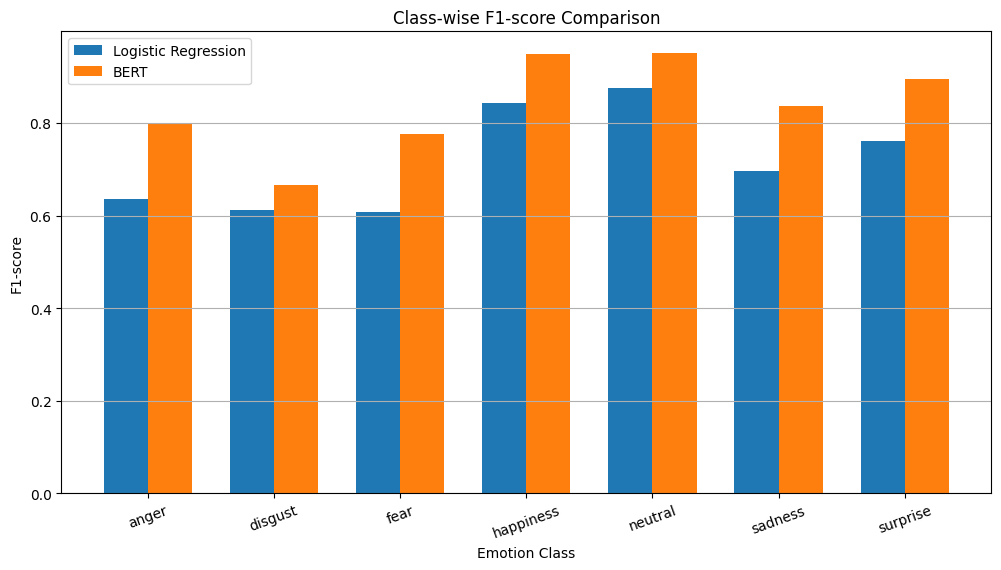

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = label_encoder.classes_

# Extract F1 scores
lr_f1 = [lr_report[label]["f1-score"] for label in labels]
bert_f1 = [bert_report[label]["f1-score"] for label in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, lr_f1, width, label="Logistic Regression")
plt.bar(x + width/2, bert_f1, width, label="BERT")

plt.xticks(x, labels, rotation=20)
plt.ylabel("F1-score")
plt.xlabel("Emotion Class")
plt.title("Class-wise F1-score Comparison")
plt.legend()

plt.grid(axis='y')
plt.show()

# 2. Example Predictions Table

# 2.1 Logistic Regression predictions table

In [ ]:
import random as rd
import pandas as pd
rand = rd.randint(0,2600)
sample_size = 10

results_lr = pd.DataFrame({
    "Text": X_test[rand:rand+sample_size],
    "True Emotion": label_encoder.inverse_transform(y_test[rand:rand+sample_size]),
    "Predicted Emotion": label_encoder.inverse_transform(y_pred_lr[rand:rand+sample_size])
})

results_lr

,Text,True Emotion,Predicted Emotion
1155,15 Steele went 5 1 in pool play with just a 6-...,happiness,happiness
1865,"Congrats to Seenane Brewer (Navajo/Cherokee), ...",happiness,happiness
12339,terrifying every time.,fear,fear
7361,Fairmont High School volleyball libero Nora Fi...,anger,neutral
12474,I'm really enjoying Season 3 but this would ru...,happiness,happiness
6169,Please join me and pledge for Livingstone Voll...,neutral,neutral
11933,There's an Arby's/Long John Silvers near where...,happiness,happiness
7808,Volleyball keeps on rolling with their 2nd str...,happiness,happiness
11241,Technically it’s the abdomen. Stomach and bell...,anger,anger
5431,Boys Volleyball won our CIF Semifinal match at...,happiness,happiness


## BERT predictions table

In [ ]:
sample_size = 100
rand = rd.randint(0,1305)
bert_texts = val_df.iloc[rand:rand+sample_size]["text"].tolist()

results_bert = pd.DataFrame({
    "Text": bert_texts,
    "True Emotion": label_encoder.inverse_transform(y_true_bert[rand:rand+sample_size]),
    "Predicted Emotion": label_encoder.inverse_transform(y_pred_bert[rand:rand+sample_size])
})

results_bert

,Text,True Emotion,Predicted Emotion
0,Pointless but fun,happiness,happiness
1,Micah Christenson and Team USA continue to acc...,happiness,happiness
2,I remember writing on them was horrible. Sligh...,fear,fear
3,"YEAAAAHH!!!!YEAAAAHHH!!!!...oh, here ya go, do...",anger,surprise
4,Can you fucking not,anger,anger
...,...,...,...
95,"I sould have assissted in the stabbing, even c...",surprise,surprise
96,"""I used to train in the same Olympic camp with...",happiness,happiness
97,NOT OUR DAY Thomasians packed the Quadricenten...,neutral,neutral
98,Outside Hitter Is THE SWORD #volleyball #indoo...,neutral,neutral


# 3. Error Analysis Table

## Misclassified tweets

In [ ]:
misclassified = results_bert[
    results_bert["True Emotion"] != results_bert["Predicted Emotion"]
]

misclassified.head(10)

,Text,True Emotion,Predicted Emotion
3,"YEAAAAHH!!!!YEAAAAHHH!!!!...oh, here ya go, do...",anger,surprise
17,Allow me to describe the shock and awe I exper...,anger,surprise
25,DegaWVB | was honored by the HBCUAC in awards ...,happiness,neutral
26,Santa Barbara beach volleyball court dedicated...,happiness,neutral
36,i once dipped a raw hot dog in chocolate puddi...,disgust,fear
37,Feeling this so hard right now. Virtual hug.,happiness,sadness
59,"It s going to be a colossal failure, and will ...",sadness,neutral
67,Vital Strategies is pleased to announce that W...,neutral,happiness
70,"For Mr. Cheese, Cameron Duffy on Facebook: ""I ...",neutral,happiness
72,This sent shivers down my spine,fear,surprise


## Enhanced manual analysis table

In [ ]:
error_examples = pd.DataFrame({
    "Tweet": misclassified["Text"].head(5),
    "True Emotion": misclassified["True Emotion"].head(5),
    "Predicted Emotion": misclassified["Predicted Emotion"].head(5),
    "Possible Reason": [
        "Implicit emotional expression",
        "Sarcasm or irony",
        "Semantic overlap between emotions",
        "Very short text with limited context",
        "Ambiguous wording"
    ]
})

error_examples

,Tweet,True Emotion,Predicted Emotion,Possible Reason
3,"YEAAAAHH!!!!YEAAAAHHH!!!!...oh, here ya go, do...",anger,surprise,Implicit emotional expression
17,Allow me to describe the shock and awe I exper...,anger,surprise,Sarcasm or irony
25,DegaWVB | was honored by the HBCUAC in awards ...,happiness,neutral,Semantic overlap between emotions
26,Santa Barbara beach volleyball court dedicated...,happiness,neutral,Very short text with limited context
36,i once dipped a raw hot dog in chocolate puddi...,disgust,fear,Ambiguous wording


# 4. Confusion Matrix

## Logistic Regression confusion matrix

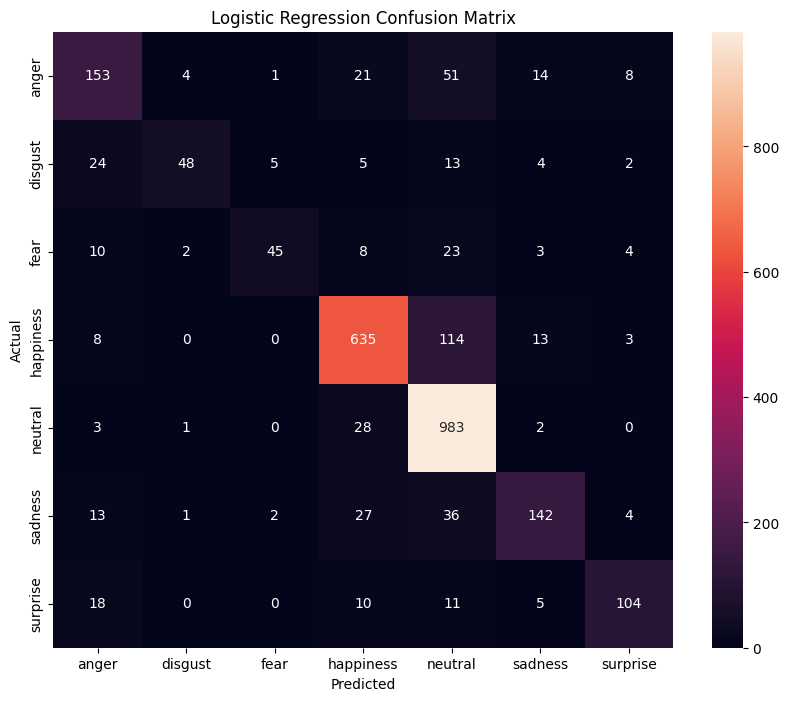

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## BERT confusion matrix

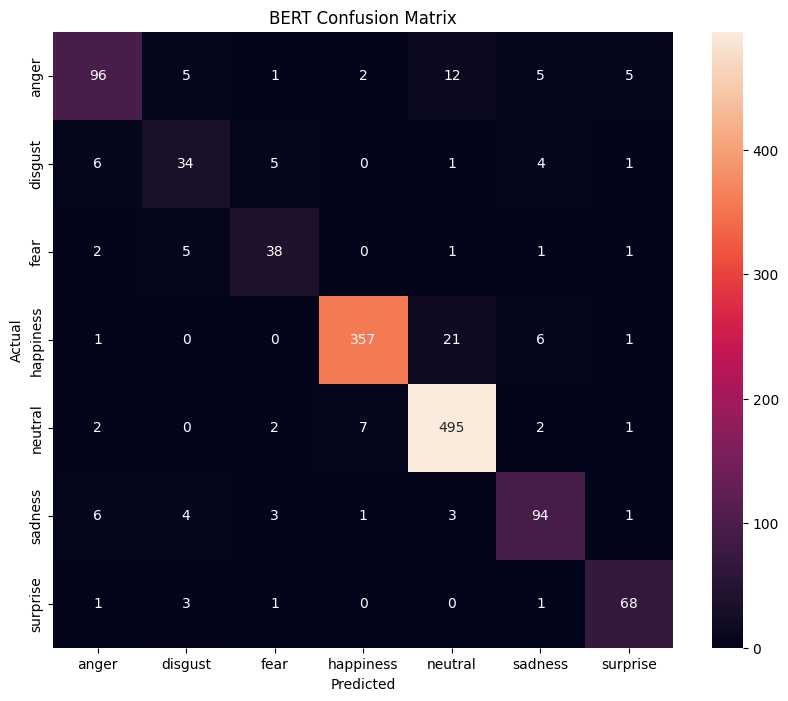

In [ ]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm_bert,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 5. McNemar Statistical Significance Test

In [ ]:
# pip install statsmodels

## McNemar test

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# Make equal size
min_len = min(len(y_pred_lr), len(y_pred_bert))

y_test_m = y_test[:min_len]
y_pred_lr_m = y_pred_lr[:min_len]
y_pred_bert_m = y_pred_bert[:min_len]

# Correct / incorrect
lr_correct = (y_pred_lr_m == y_test_m)
bert_correct = (y_pred_bert_m == y_test_m)

# Contingency table
both_correct = np.sum((lr_correct == True) & (bert_correct == True))
lr_only = np.sum((lr_correct == True) & (bert_correct == False))
bert_only = np.sum((lr_correct == False) & (bert_correct == True))
both_wrong = np.sum((lr_correct == False) & (bert_correct == False))

table = [
    [both_correct, lr_only],
    [bert_only, both_wrong]
]

# McNemar test
result = mcnemar(table, exact=False)

print("Contingency table:")
print(table)

print("\nMcNemar statistic:", result.statistic)
print("p-value:", result.pvalue)

Contingency table:
[[np.int64(311), np.int64(750)], [np.int64(38), np.int64(207)]]

McNemar statistic: 641.524111675127
p-value: 1.557644551870793e-141


# 7. Attention Visualization

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True
)

text = "What a terrible referee decision!"

result = classifier(text)

print(result)

[{'label': 'LABEL_2', 'score': 0.9117772579193115}]


# 2. Class-wise F1-score Comparison

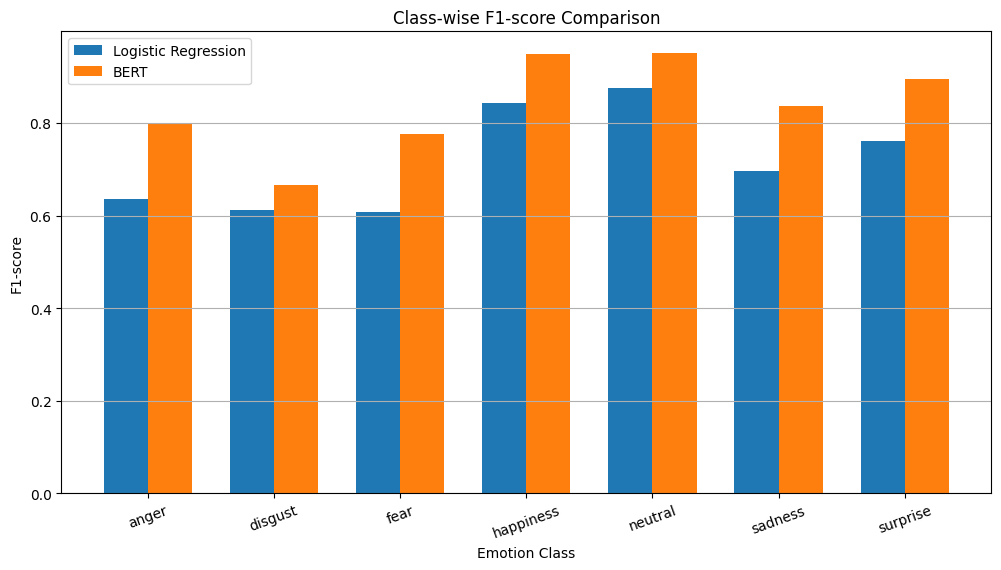

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Logistic Regression
# =========================

# True labels
y_true_lr = y_test

# Predictions
y_pred_lr = logistic_model.predict(X_test_tfidf)

# Classification report
lr_report = classification_report(
    y_true_lr,
    y_pred_lr,
    target_names=label_encoder.classes_,
    output_dict=True
)

# =========================
# BERT
# =========================

# BERT predictions
predictions = trainer.predict(val_dataset)

y_pred_bert = np.argmax(predictions.predictions, axis=1)
y_true_bert = predictions.label_ids

bert_report = classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_encoder.classes_,
    output_dict=True
)

# =========================
# Extract F1 scores
# =========================

labels = label_encoder.classes_

lr_f1 = [lr_report[label]["f1-score"] for label in labels]
bert_f1 = [bert_report[label]["f1-score"] for label in labels]

# =========================
# Plot
# =========================

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    lr_f1,
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width/2,
    bert_f1,
    width,
    label="BERT"
)

plt.xticks(x, labels, rotation=20)

plt.ylabel("F1-score")
plt.xlabel("Emotion Class")

plt.title("Class-wise F1-score Comparison")

plt.legend()

plt.grid(axis='y')

plt.show()

# 3. LIME для BERT

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8c75226663d2a31643f613d064e50354edafc688c37a6b17cccb6ac65d3daebd
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
!pip install shap

## 3.1 SHAP для BERT

In [ ]:
import shap

# Обёртка для SHAP (ожидает на вход список строк, возвращает логиты)
def bert_predict_for_shap(texts):
    inputs = tokenizer(texts, return_tensors='pt', truncation=True,
                       padding=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits.cpu().numpy()
    return logits

# Используем маскировку токенов (partition explainer для текста)
# SHAP встроенными методами для Transformer работает медленно, поэтому эффективнее:
# 1) взять несколько примеров для background
background = df['text'].iloc[:50].tolist()  # 50 примеров для baseline

# Создаём explainer с масками на уровне токенов (учитывает контекст BERT)
explainer_shap = shap.Explainer(bert_predict_for_shap, background,
                                feature_names=tokenizer.tokenize("пример"),
                                algorithm="partition")

# Объясняем один пример
text_example = df.iloc[idx]['text']
shap_values = explainer_shap([text_example], fixed_context=1)

# Визуализация SHAP
shap.initjs()
# Для текстов используем специфический plot
shap.plots.text(shap_values, class_names=class_names, max_display=15)
plt.savefig('shap_bert_explanation.png', bbox_inches='tight')

## 3.2 Сравнение с логистической регрессией

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Предполагаем, что вы уже обучили векторйзер и LR:
# vectorizer = TfidfVectorizer(max_features=5000)
# X_train = vectorizer.fit_transform(df_train['text'])
# lr.fit(X_train, y_train)

def predict_proba_lr(texts):
    X = vectorizer.transform(texts)
    return lr.predict_proba(X)

# LIME для LR
explainer_lr = LimeTextExplainer(class_names=class_names)
exp_lr = explainer_lr.explain_instance(
    text_example,
    predict_proba_lr,
    num_features=10,
    num_samples=5000,
    labels=[class_names.index(true_label)]
)
exp_lr.show_in_notebook(text=text_example)

In [ ]:
# 📈 3. Предсказания на тесте
predictions = trainer.predict(dataset["test"])


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset = dataset.map(lambda x: {
    "labels": le.fit_transform([x["emotion"]])[0]
})

Map:   0%|          | 0/6968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

In [ ]:

# dataset = dataset.rename_column("emotion", "labels")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["labels"] = le.fit_transform(df["emotion"])


from datasets import Dataset

dataset = Dataset.from_pandas(df)

In [ ]:
dataset = dataset.train_test_split(test_size=0.2)

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True)

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/6968 [00:00<?, ? examples/s]

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

In [ ]:
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
dataset['test']['labels']

Column([tensor(3), tensor(3), tensor(4), tensor(4), tensor(4)])

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
predictions = trainer.predict(dataset["test"])

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        51
           1       1.00      1.00      1.00         1
           2       1.00      0.83      0.91         6
           3       0.99      1.00      0.99       622
           4       0.99      1.00      1.00       996
           5       0.97      0.97      0.97        65
           6       1.00      0.50      0.67         2

    accuracy                           0.99      1743
   macro avg       0.99      0.89      0.93      1743
weighted avg       0.99      0.99      0.99      1743



In [ ]:
import random as rd

In [ ]:
import torch

# Названия классов
label_names = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "neutral",
    "sadness",
    "surprise"
]

def predict_emotion(text):
    # Токенизация
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Перенос на GPU если модель на CUDA
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Предсказание
    with torch.no_grad():
        outputs = model(**inputs)

    # Получаем индекс класса
    predicted_class = torch.argmax(outputs.logits, dim=1).item()

    # Возвращаем эмоцию
    return label_names[predicted_class]



In [ ]:
# Пример
text = "I work out. He was part of the team that got us out of VNL & contributed hugely. His appearances were restricted by injury last season but let s not forget his previous season. I hope he finds a decent team in the coming weeks. Always welcome at the St k Cae Ras"
prediction = predict_emotion(text)

print("Text:", text)
print("Predicted emotion:", prediction)

Text: I work out. He was part of the team that got us out of VNL & contributed hugely. His appearances were restricted by injury last season but let s not forget his previous season. I hope he finds a decent team in the coming weeks. Always welcome at the St k Cae Ras
Predicted emotion: fear


In [ ]:
[label_names[i] for i in y_true[:5]]

['happiness', 'happiness', 'neutral', 'neutral', 'neutral']

In [ ]:
list(df[df['Unnamed: 0'] == 1174].text)

['I think it did work out. He was part of the team that got us out of VNL & contributed hugely. His appearances were restricted by injury last season but let s not forget his previous season. I hope he finds a decent team in the coming weeks. Always welcome at the St k Cae Ras']

In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# Предсказания
predictions = trainer.predict(dataset["test"])

# Индексы классов
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Названия эмоций
label_names = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "neutral",
    "sadness",
    "surprise"
]

# Количество примеров
sample_size = 5 #rd.randint(0,1700)

# Берем тексты напрямую из df
sample_texts = df.iloc[sample_size:sample_size+5]["text"].tolist()

# Создаем таблицу
results_df = pd.DataFrame({
    "Text": sample_texts,
    "Real Emotion": [label_names[i] for i in y_true[:sample_size]],
    "Predicted Emotion": [label_names[i] for i in y_pred[:sample_size]]
})

print(tabulate(results_df, headers='keys', tablefmt='grid'))

+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------+---------------------+
|    | Text                                                                                                                                                                                                                                                | Real Emotion   | Predicted Emotion   |
+====+=====================================================================================================================================================================================================================================================+================+=====================+
|  0 | I remember when the comentator said japan is everywhere at match vnl or olympics and ITS TRUE NOW WKWKWKWK           

In [ ]:

print(dataset["test"].column_names)

['Unnamed: 0', 'text', 'emotion', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


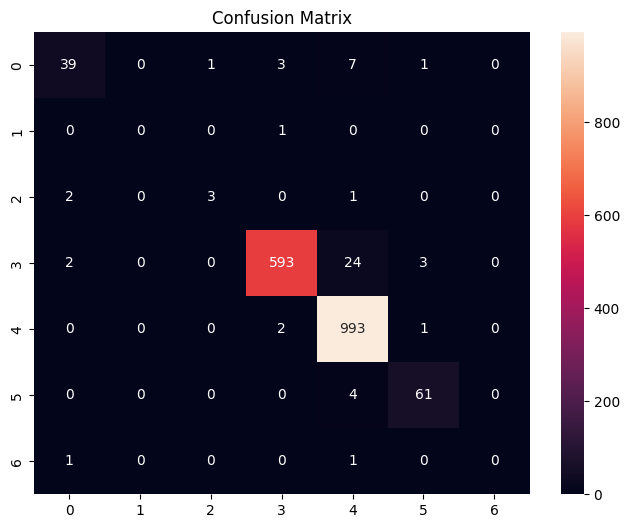

In [ ]:
# 3.1. Матрица ошибок (обязательно)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 🔥 ВАЖНО — отправляем на тот же device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    return label_names[pred_id]

In [ ]:
predict("What a fantastic match!!!")

'sadness'

# Сохраняем модель

In [ ]:
trainer.save_model("my_emotion_model")
tokenizer.save_pretrained("my_emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_emotion_model/tokenizer_config.json', 'my_emotion_model/tokenizer.json')

In [ ]:
# Как загрузить модель потом
from transformers import BertTokenizer, BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained("my_emotion_model")
tokenizer = BertTokenizer.from_pretrained("my_emotion_model")

In [ ]:
## Используем послу загрузки
import torch

label_names = ["neutral", "happiness", "anger", "disgust", "sadness", "surprise", "fear"]

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()
    return label_names[pred_id]

# Adding data

In [ ]:
"""
Скрипт для загрузки и фильтрации GoEmotions под 7 базовых эмоций (Экман + нейтральный)
Результат: 5000 случайных примеров в CSV-файле
"""

import pandas as pd
from datasets import load_dataset

# -------------------------------------------------------------------
# 1. ЗАГРУЗКА ДАННЫХ
# -------------------------------------------------------------------
print("Загрузка GoEmotions dataset с HuggingFace...")
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

# Берем тренировочную часть (43k примеров)
train_data = dataset["train"]
print(f"Загружено примеров: {len(train_data)}")

# -------------------------------------------------------------------
# 2. МАППИНГ ЭМОЦИЙ GoEmotions -> ВАШИ МЕТКИ
# -------------------------------------------------------------------
# В GoEmotions "simplified" версии эмоции обозначены индексами:
# 0: admiration, 1: amusement, 2: anger, 3: annoyance, 4: approval,
# 5: caring, 6: confusion, 7: curiosity, 8: desire, 9: disappointment,
# 10: disapproval, 11: disgust, 12: embarrassment, 13: excitement,
# 14: fear, 15: gratitude, 16: grief, 17: joy, 18: love, 19: nervousness,
# 20: optimism, 21: pride, 22: realization, 23: relief, 24: remorse,
# 25: sadness, 26: surprise, 27: neutral

# Ваши целевые метки и соответствующие индексы в GoEmotions
target_emotions = {
    "neutral": 27,
    "happiness": 17,      # joy в GoEmotions
    "sadness": 25,
    "anger": 2,           # anger в GoEmotions
    "fear": 14,
    "surprise": 26,
    "disgust": 11
}

# Обратный маппинг: индекс -> название вашей метки
idx_to_label = {v: k for k, v in target_emotions.items()}

print("\nЦелевые эмоции и их индексы в GoEmotions:")
for label, idx in target_emotions.items():
    print(f"  {label} -> индекс {idx}")

# -------------------------------------------------------------------
# 3. ФИЛЬТРАЦИЯ: оставляем только примеры с ОДНОЙ целевой эмоцией
# -------------------------------------------------------------------
print("\nФильтрация данных...")

filtered_texts = []
filtered_labels = []

for item in train_data:
    labels = item["labels"]  # список индексов эмоций для этого текста

    # Проверяем, есть ли у текста ровно одна эмоция
    if len(labels) != 1:
        continue

    emotion_idx = labels[0]

    # Проверяем, входит ли эта эмоция в наш список целевых
    if emotion_idx in target_emotions.values():
        filtered_texts.append(item["text"])
        filtered_labels.append(idx_to_label[emotion_idx])

print(f"После фильтрации осталось: {len(filtered_texts)} примеров")

# -------------------------------------------------------------------
# 4. ПРОВЕРКА РАСПРЕДЕЛЕНИЯ ПО КЛАССАМ
# -------------------------------------------------------------------
df_full = pd.DataFrame({
    "text": filtered_texts,
    "label": filtered_labels
})

print("\nРаспределение по классам (все отфильтрованные данные):")
print(df_full["label"].value_counts())

# -------------------------------------------------------------------
# 5. ВЫБОРКА 5000 СЛУЧАЙНЫХ ПРИМЕРОВ (с сохранением пропорций)
# -------------------------------------------------------------------
print("\n" + "="*50)
print("Создание выборки из 5000 примеров...")

n_samples = 43410

# Если данных больше 5000, берем случайную выборку
if len(df_full) > n_samples:
    df_sample = df_full.sample(n=n_samples, random_state=42)
else:
    df_sample = df_full
    print(f"Внимание: данных всего {len(df_full)}, что меньше запрошенных {n_samples}")

print("\nРаспределение по классам в итоговой выборке:")
print(df_sample["label"].value_counts())



Загрузка GoEmotions dataset с HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Загружено примеров: 43410

Целевые эмоции и их индексы в GoEmotions:
  neutral -> индекс 27
  happiness -> индекс 17
  sadness -> индекс 25
  anger -> индекс 2
  fear -> индекс 14
  surprise -> индекс 26
  disgust -> индекс 11

Фильтрация данных...
После фильтрации осталось: 17166 примеров

Распределение по классам (все отфильтрованные данные):
label
neutral      12823
anger         1025
happiness      853
sadness        817
surprise       720
disgust        498
fear           430
Name: count, dtype: int64

Создание выборки из 5000 примеров...
Внимание: данных всего 17166, что меньше запрошенных 43410

Распределение по классам в итоговой выборке:
label
neutral      12823
anger         1025
happiness      853
sadness        817
surprise       720
disgust        498
fear           430
Name: count, dtype: int64


In [ ]:
df_sample[df_sample.label != 'neutral']

,text,label
2,WHY THE FUCK IS BAYLESS ISOING,anger
3,To make her feel threatened,fear
4,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,surprise
7,Fucking coward.,anger
12,Stupidly stubborn / stubbornly stupid,anger
...,...,...
17144,That's a cool dino,happiness
17149,Shhh don't give them the idea!,anger
17155,"Downtown is inconvenient, look like you've gon...",happiness
17159,My inevitable famine is when I run out of pop ...,sadness


In [ ]:
# -------------------------------------------------------------------
# 6. СОХРАНЕНИЕ В CSV
# -------------------------------------------------------------------
output_file = "new_data_to_add.csv"
df_sample[df_sample.label != 'neutral'].to_csv(output_file, index=False, encoding="utf-8")
print(f"\nДанные сохранены в файл: {output_file}")
print(f"Всего строк: {len(df_sample)}")
print(f"Колонки: {list(df_sample.columns)}")

# -------------------------------------------------------------------
# 7. ПОКАЗЫВАЕМ ПРИМЕРЫ (для проверки)
# -------------------------------------------------------------------
print("\n" + "="*50)
print("Примеры из датасета:")

for emotion in df_sample["label"].unique():
    example = df_sample[df_sample["label"] == emotion].iloc[0]
    print(f"\n[{emotion.upper()}] {example['text'][:100]}...")


Данные сохранены в файл: new_data_to_add.csv
Всего строк: 17166
Колонки: ['text', 'label']

Примеры из датасета:

[NEUTRAL] My favourite food is anything I didn't have to cook myself....

[ANGER] WHY THE FUCK IS BAYLESS ISOING...

[FEAR] To make her feel threatened...

[SURPRISE] OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015....

[HAPPINESS] Happy to be able to help....

[SADNESS] Pretty sure I’ve seen this. He swings away with the harness he is wearing. Still looks painful but I...

[DISGUST] youre a disgusting piece of filth....


In [ ]:
df_sample.label.value_counts()

,count
label,
neutral,3713
anger,292
happiness,248
sadness,240
surprise,222
disgust,154
fear,131


# v2 Adding data

In [ ]:
"""
Скрипт для загрузки GoEmotions и фильтрации:
1. Только 7 целевых эмоций (neutral, happiness, sadness, anger, fear, surprise, disgust)
2. Только комментарии из спортивных сабреддитов
Результат: случайная выборка из N строк в CSV
"""

import pandas as pd
import numpy as np

# -------------------------------------------------------------------
# 1. ЗАГРУЗКА RAW DATA (содержит колонку subreddit)
# -------------------------------------------------------------------
print("Загрузка raw GoEmotions данных...")

urls = [
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_1.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_2.csv",
    "https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_3.csv"
]

# Скачиваем и объединяем все три файла
dfs = []
for i, url in enumerate(urls, 1):
    print(f"  Загрузка файла {i}/3...")
    df_part = pd.read_csv(url)
    dfs.append(df_part)
    print(f"    Загружено {len(df_part)} строк")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nВсего загружено: {len(df_raw)} строк")
print(f"Колонки: {list(df_raw.columns)}")

# -------------------------------------------------------------------
# 2. ОПРЕДЕЛЕНИЕ ЭМОЦИЙ И ИХ КОЛОНОК
# -------------------------------------------------------------------
# Список всех 28 эмоций в GoEmotions (в порядке колонок)
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Маппинг: ваши метки -> колонки в GoEmotions
target_mapping = {
    "neutral": "neutral",
    "happiness": "joy",      # joy -> happiness
    "sadness": "sadness",
    "anger": "anger",
    "fear": "fear",
    "surprise": "surprise",
    "disgust": "disgust"
}

# -------------------------------------------------------------------
# 3. ФИЛЬТРАЦИЯ: ТОЛЬКО СПОРТИВНЫЕ САБРЕДДИТЫ
# -------------------------------------------------------------------
print("\n" + "="*50)
print("Фильтрация по спортивным сабреддитам...")

sports_subreddits = [
    'nfl', 'sports', 'nba', 'soccer', 'baseball',
    'hockey', 'MLS', 'CFB', 'MMA', 'boxing'
]

# Приводим к нижнему регистру для надежного сравнения
df_raw['subreddit_lower'] = df_raw['subreddit'].str.lower()
df_sports = df_raw[df_raw['subreddit_lower'].isin(sports_subreddits)].copy()
print(f"Найдено комментариев из спортивных сабреддитов: {len(df_sports)}")

if len(df_sports) == 0:
    print("Внимание: не найдено комментариев из указанных сабреддитов.")
    print("Доступные сабреддиты в данных:", df_raw['subreddit'].unique()[:20])
    exit()

# -------------------------------------------------------------------
# 4. ФИЛЬТРАЦИЯ: ТОЛЬКО ТЕКСТЫ С ОДНОЙ ЦЕЛЕВОЙ ЭМОЦИЕЙ
# -------------------------------------------------------------------
print("\nФильтрация по эмоциям...")

filtered_texts = []
filtered_labels = []
filtered_subreddits = []

for idx, row in df_sports.iterrows():
    # Определяем, какие эмоции есть у этого текста
    present_emotions = [e for e in emotions if row[e] == 1]

    # Оставляем только если ровно одна эмоция
    if len(present_emotions) != 1:
        continue

    emotion = present_emotions[0]

    # Проверяем, входит ли эта эмоция в наши целевые
    if emotion in target_mapping.values():
        # Находим вашу метку
        for your_label, go_label in target_mapping.items():
            if go_label == emotion:
                filtered_texts.append(row['text'])
                filtered_labels.append(your_label)
                filtered_subreddits.append(row['subreddit'])
                break

print(f"После фильтрации по эмоциям осталось: {len(filtered_texts)} примеров")

# -------------------------------------------------------------------
# 5. ПРОВЕРКА РАСПРЕДЕЛЕНИЯ
# -------------------------------------------------------------------
df_filtered = pd.DataFrame({
    "text": filtered_texts,
    "label": filtered_labels,
    "subreddit": filtered_subreddits
})

print("\nРаспределение по классам:")
print(df_filtered["label"].value_counts())

print("\nРаспределение по сабреддитам:")
print(df_filtered["subreddit"].value_counts())



Загрузка raw GoEmotions данных...
  Загрузка файла 1/3...
    Загружено 70000 строк
  Загрузка файла 2/3...
    Загружено 70000 строк
  Загрузка файла 3/3...
    Загружено 71225 строк

Всего загружено: 211225 строк
Колонки: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Фильтрация по спортивным сабреддитам...
Найдено комментариев из спортивных сабреддитов: 1853

Фильтрация по эмоциям...
После фильтрации по эмоциям осталось: 751 примеров

Распределение по классам:
label
neutral      533
anger         52
happiness     49
surprise      47
disgust       32
sadness       30
fear           8
Name: c

In [ ]:
df_filtered

,text,label,subreddit
0,This video doesn't even show the shoes he was ...,neutral,Boxing
1,I wouldnt mind seeig a few rushes with that NF...,neutral,hockey
2,Hey guys. Just made some dinner. Came to see t...,surprise,hockey
3,say it with me now super star,neutral,nba
4,Worrying about [NAME] during a game is ridicul...,fear,nba
...,...,...,...
746,but but TIME IS MONEY right?,neutral,soccer
747,I’m not crying. You’re crying,neutral,nba
748,"When you live where it's this cold, incessant ...",disgust,hockey
749,Intentional fouling in basketball too thiugh,neutral,sports


In [ ]:
# -------------------------------------------------------------------
# 6. ВЫБОРКА N СЛУЧАЙНЫХ ПРИМЕРОВ
# -------------------------------------------------------------------
n_samples = 5000

if len(df_filtered) >= n_samples:
    df_sample = df_filtered.sample(n=n_samples, random_state=42)
else:
    df_sample = df_filtered
    print(f"\nВнимание: спортивных данных только {len(df_filtered)}, берем все")

print(f"\nИтоговый размер выборки: {len(df_sample)}")

# -------------------------------------------------------------------
# 7. СОХРАНЕНИЕ
# -------------------------------------------------------------------
output_file = "sports_emotion_data_5000.csv"
df_sample[["text", "label"]].to_csv(output_file, index=False, encoding="utf-8")
print(f"\nДанные сохранены в: {output_file}")

# Показываем примеры
print("\n" + "="*50)
print("Примеры из датасета:")
for emotion in df_sample["label"].unique():
    example = df_sample[df_sample["label"] == emotion].iloc[0]
    print(f"\n[{emotion.upper()}] (из {example['subreddit']}): {example['text'][:100]}...")